# Análisis de rentabilidad de planes telefónicos de la empresa de telecomunicaciones **Megaline**

## Propósito del proyecto

El objetivo central de este proyecto es realizar un análisis comparativo preliminar entre las tarifas de prepago **Surf** y **Ultimate** de la empresa de telecomunicaciones **Megaline**. A través de la evaluación del comportamiento de consumo de una muestra representativa de 500 clientes durante el año 2018, se busca identificar **cuál de los dos planes genera un mayor volumen de ingresos comerciales**. 

Los resultados y conclusiones obtenidos permitirán al departamento de marketing y estrategia comercial optimizar de manera eficiente la asignación del presupuesto de publicidad para el próximo ciclo fiscal.

## Plan de trabajo

A continuación se detalla la hoja de ruta metodológica y técnica estructurada para la ejecución integral del proyecto. Dicha hoja de ruta está orientada a cuál de los dos planes de tarifa prepago genera un mayor volumen de ingresos.

<div style="background-color: #f8f9fa; border: 1px solid #e9ecef; padding: 20px; border-radius: 8px; text-align: center; font-family: sans-serif; margin: 20px 0;"><h4 style="color: #495057; margin-top: 0; margin-bottom: 15px; font-size: 14px; letter-spacing: 1px; text-transform: uppercase;">DIAGRAMA DE LA RUTA METODOLÓGICA DEL PROYECTO</h4><span style="background-color: #03a9f4; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">1. Inicialización y Exploración</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #6c757d; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">2. Preprocesamiento y Preparación</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #6c757d; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">3. Análisis Exploratorio (EDA)</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #ff9800; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">4. Pruebas de Hipótesis</span><span style="color: #6c757d; margin: 0 8px; font-weight: bold;">➔</span><span style="background-color: #28a745; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold; font-size: 12px; display: inline-block; margin: 5px 0;">5. Diagnóstico y Conclusiones</span></div>

Para resolver la problemática planteada y garantizar la robustez metodológica del análisis, se ejecutarán las fases consecutivas ilustradas en el diagrama anterior, las cuales se desglosan a continuación:

### 1. Inicialización y exploración de datos
* **Carga de los datasets** correspondientes a usuarios, llamadas, mensajes, sesiones de internet y parámetros de las tarifas.
* **Inspección inicial** de las estructuras utilizando `.info()` y `.head()` para diagnosticar tipos de datos, inconsistencias o valores faltantes.

### 2. Preprocesamiento y preparación de la información
* **Conversión cronológica:** Transformación de las variables de fecha de formato de texto (`object`) a tipo temporal (`datetime`).
* **Aplicación de reglas de negocio:** Implementación del redondeo individual hacia arriba para la duración de las llamadas mediante `np.ceil()`.
* **Agregación mensual:** Consolidación de datos por usuario y por mes para calcular el consumo neto de minutos, SMS y volumen total de datos en Megabytes.
* **Conversión y redondeo web:** Transformación del tráfico mensual de datos de Megabytes a Gigabytes, aplicando el redondeo reglamentario hacia arriba.
* **Cálculo de ingresos netos:** Desarrollo de una función lógica para calcular la facturación mensual por usuario, sumando la cuota fija del plan y las penalizaciones por consumos excedentes.

### 3. Análisis exploratorio de datos
* **Estadística descriptiva:** Cálculo de la media, la varianza y la desviación estándar para las tres variables de consumo y los ingresos de cada tarifa.
* **Visualización de distribuciones:** Generación de histogramas comparativos y diagramas de caja (`boxplots`) para comprender la dispersión y la asimetría del comportamiento de los clientes.

### 4. Pruebas de hipótesis estadísticas
* **Validación de ingresos por tarifa:** Formulación y ejecución de una prueba $t$ de Student de muestras independientes para determinar si el ingreso promedio entre los usuarios de Surf y Ultimate difiere significativamente.
* **Validación de ingresos por región géographique:** Segmentación de los usuarios para comprobar estadísticamente si los clientes del área de Nueva York-Nueva Jersey aportan ingresos distintos al resto de las regiones del país.

### 5. Diagnóstico y conclusión general
* **Síntesis analítica:** Interpretación final de los resultados estadísticos obtenidos.
* **Recomendación estratégica:** Presentación de conclusiones claras orientadas a la toma de decisiones sobre la distribución del presupuesto publicitario.


## Inicialización

In [1]:
# ================================================
# Se cargan las librerías necesarias
# ================================================
import numpy as np
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt

## Cargar datos

In [2]:
# =====================================================================
# Cargar de los archivos de datos en sus respectivos DataFrames 
# =====================================================================

df_users = pd.read_csv("/Users/alfredoenrique/Ejer_Curs_Pyth/Sprint_05/Proyecto_05/megaline_users.csv")
df_calls = pd.read_csv("/Users/alfredoenrique/Ejer_Curs_Pyth/Sprint_05/Proyecto_05/megaline_calls.csv")
df_messages = pd.read_csv("/Users/alfredoenrique/Ejer_Curs_Pyth/Sprint_05/Proyecto_05/megaline_messages.csv")
df_internet = pd.read_csv("/Users/alfredoenrique/Ejer_Curs_Pyth/Sprint_05/Proyecto_05/megaline_internet.csv")
df_plans = pd.read_csv("/Users/alfredoenrique/Ejer_Curs_Pyth/Sprint_05/Proyecto_05/megaline_plans.csv")

## Preparar los datos

In [3]:
# ===============================================================
# Exploración de cada uno de los DataFrames
# ===============================================================

# Se muestra información del DataFrame df_user
print("=== Exploración del DataFrame df_user (Usuarios) ===")
df_users.info()
print()
print(df_users.head(5))

print()

# Se muestra información del DataFrame df_calls
print("=== Exploración del DataFrame df_calls (Llamadas) ===")
df_calls.info()
print()
print(df_calls.head(5))

print()

# Se muestra información del DataFrame df_messages
print("=== Exploración del DataFrame df_messages (Mensajes) ===")
df_messages.info()
print()
print(df_messages.head(5))

print()

# Se muestra información del DataFrame df_internet
print("=== Exploración del DataFrame df_internet (Internet) ===")
df_internet.info()
print()
print(df_internet.head(5))

print()

# Se muestra información del DataFrame df_plans
print("=== Exploración del DataFrame df_plans (tarifas) ===")
df_plans.info()
print()
print(df_plans.head(5))

=== Exploración del DataFrame df_user (Usuarios) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, O

In [4]:
# ===============================================================
# Correcciones requeridas en cada uno de los DataFrames
# ===============================================================

### 1. Para el DataFrame: df_user.
# Se convierten fechas de texto a datetime.
# Manejo de nulos en churn_date: No se suprimen. Los nulos significan que el usuario sigue activo.
# Pueden dejarse como NaT o rellenarlos con una fecha futura/marcador si el análisis lo requiere.
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

### 2. Para el DataFrame: df_calls
# Se convierten fechas de texto a datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')
# Aplicación de la regla Megaline: Las llamadas se redondean hacia arriba al minuto entero inmediatamente posterior
# Ejemplo: 0.1 minutos se convierte en 1.0 minuto.
df_calls['duration'] = np.ceil(df_calls['duration']).astype(int)


### 3. Para el DataFrame: df_messages
# Se convierten fechas de texto a datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')


### 4. Para el DataFrame: df_internet
# Se convierten fechas de texto a datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

# Observación: El tráfico de internet se redondea al final del mes (en gigabytes), no por sesión.
# Por ahora, se dejan los megabytes de cada sesión tal como están.

### 5. Se verifican de los cambios realizados
print("=== Verificación de tipos de datos actualizados ===")
print(f"Users - reg_date: {df_users['reg_date'].dtype}, churn_date: {df_users['churn_date'].dtype}")
print(f"Calls - call_date: {df_calls['call_date'].dtype}, duration (ejemplo): {df_calls['duration'].head(2).tolist()}")
print(f"Messages - message_date: {df_messages['message_date'].dtype}")
print(f"Internet - session_date: {df_internet['session_date'].dtype}")


=== Verificación de tipos de datos actualizados ===
Users - reg_date: datetime64[ns], churn_date: datetime64[ns]
Calls - call_date: datetime64[ns], duration (ejemplo): [9, 14]
Messages - message_date: datetime64[ns]
Internet - session_date: datetime64[ns]


### Resumen de hallazgos y correcciones de datos

Tras realizar la exploración inicial con `.info()` y `.head()` en los cinco conjuntos de datos, se identificaron y aplicaron las siguientes modificaciones:

#### Hallazgos identificados
* **Formatos de fecha incorrectos:** Las columnas de fechas (`reg_date`, `churn_date`, `call_date`, `message_date`, `session_date`) se cargaron originalmente como texto (`object`).
* **Valores ausentes en `churn_date`:** El DataFrame `df_users` presenta valores nulos en la fecha de baja. Esto es normal e indica que los clientes siguen activos con el servicio.
* **Regla de redondeo de llamadas:** Megaline contabiliza las llamadas redondeando los segundos hacia arriba al minuto entero más cercano.

#### Correcciones aplicadas
* **Conversión a Datetime:** Se transformaron todas las columnas de fechas al tipo `datetime64[ns]` mediante `pd.to_datetime()` para permitir la extracción posterior de meses.
* **Manejo de nulos:** Se conservaron intactos los valores nulos en `churn_date` (quedando como `NaT`) para evitar distorsiones en los usuarios activos.
* **Redondeo de duración:** Se aplicó `np.ceil()` seguido de `.astype(int)` en la columna `duration` de `df_calls` para cumplir con las políticas de facturación de la empresa.

### Tarifas

In [5]:

# ==============================================================================
# Información general y resumida sobre el DataFrame df_plans (tarifas)
# ==============================================================================

print("=== Estructura técnica del DataFrame df_plans (tarifas) ===")
# Muestra el total de filas, columnas, tipos de datos y si hay valores nulos
df_plans.info()

print("\n=== Dimensiones del DataFrame df_plans (tarifas) ===")
# Devuelve una tupla con (filas, columnas)
print(f"Cantidad de filas: {df_plans.shape[0]} | Cantidad de columnas: {df_plans.shape[1]}")



=== Estructura técnica del DataFrame df_plans (tarifas) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes

=== Dimensiones del DataFrame df_plans (tarifas) ===
Cantidad de filas: 2 | Cantidad de columnas: 8


In [6]:
# ==============================================================================
# Muestra de datos del DataFrame df_plans (tarifas)
# ==============================================================================

print("=== Muestra del DataFrame df_plans (tarifas) ===")
# Se muestra completo el DataFrame df_plans (tarifas) en formato vertical
print(df_plans.head().T)



=== Muestra del DataFrame df_plans (tarifas) ===
                           0         1
messages_included         50      1000
mb_per_month_included  15360     30720
minutes_included         500      3000
usd_monthly_pay           20        70
usd_per_gb                10         7
usd_per_message         0.03      0.01
usd_per_minute          0.03      0.01
plan_name               surf  ultimate


### Diagnóstico y observaciones del DataFrame `df_plans` (tarifas)

Tras evaluar la estructura técnica con `.info()` y la muestra de los datos comerciales impresos, se presentan las siguientes conclusiones analíticas:

#### Lo que se observa:
* **Integridad total:** El DataFrame contiene únicamente **2 filas** (una para el plan *Surf* y otra para *Ultimate*) y no presenta ningún valor nulo o dato ausente de origen.
* **Tipos de datos técnicos:** Los formatos asignados son consistentes con la naturaleza de las variables. Los límites de uso se almacenan como enteros (`int64`), mientras que las tarifas de cobro y penalización se manejan correctamente como decimales (`float64`).

#### Problemas detectados que requieren investigación y cambios:
1. **Incongruencia de unidades en internet (El gran problema oculto):** La columna de datos incluidos está expresada en megabytes (`mb_per_month` o `mb_per_month_included`), pero el cobro por exceso se factura por gigabytes (`usd_per_gb`). Intentar restar directamente el consumo mensual del usuario sin homogeneizar las unidades provocará graves errores matemáticos y financieros.
2. **Discrepancia en los nombres de columnas:** La columna que identifica el tipo de tarifa se llama habitualmente `plan_name` en esta tabla, mientras que en el DataFrame de usuarios (`df_users`) se llama simplemente `plan`. Esto bloqueará cualquier intento de unión automática (`merge`) entre tablas si no se estandariza previamente.

#### ¿Cómo se puede arreglar? (Plan de Acción):
* **Estandarizar a gigabytes:** Se creará una nueva columna llamada `gb_per_month` dividiendo el límite de megabytes entre `1024` (1 Gb = 1024 Mb), forzando el resultado a tipo entero (`astype(int)`). Posteriormente, se eliminará la columna vieja de megabytes para mantener el orden.
* **Homologar la clave de unión:** Se renombrará la columna `plan_name` a `plan` mediante el método `.rename(columns={...})` para unificar los identificadores de coincidencia y facilitar la posterior fusión de los DataFrames de consumo.


## Corregir datos

In [7]:
# =======================================================
# Corrección de problemas obvios en df_plans (tarifas). 
# =======================================================

# 1. Se homologa el nombre de la columna para permitir la unión (merge) futura con usuarios
# Se cambia 'plan_name' por 'plan' para que coincida exactamente con df_users
if 'plan_name' in df_plans.columns:
    df_plans = df_plans.rename(columns={'plan_name': 'plan'})

# 2. Se convierte el límite mensual de megabytes a gigabytes (1 Gb = 1024 Mb)
# Se busca el nombre de columna que tenga (mb_per_month o mg_per_month)
if 'mb_per_month' in df_plans.columns:
    df_plans['gb_per_month'] = (df_plans['mb_per_month'] / 1024).astype(int)
    df_plans = df_plans.drop(columns=['mb_per_month'])
elif 'mg_per_month' in df_plans.columns:
    df_plans['gb_per_month'] = (df_plans['mg_per_month'] / 1024).astype(int)
    df_plans = df_plans.drop(columns=['mg_per_month'])
elif 'mb_per_month_included' in df_plans.columns:
    df_plans['gb_per_month'] = (df_plans['mb_per_month_included'] / 1024).astype(int)
    df_plans = df_plans.drop(columns=['mb_per_month_included'])

# 3. Se verifican los cambios aplicados
print("=== DataFrame df_plans (tarifas) corregido y optimizado ===")
print(df_plans.T.to_string(index=False))


=== DataFrame df_plans (tarifas) corregido y optimizado ===
    0        1
   50     1000
  500     3000
   20       70
   10        7
 0.03     0.01
 0.03     0.01
 surf ultimate
   15       30


## Enriquecer los datos

In [8]:
# ==============================================================================
# Factores adicionales para el análisis del df_plans (tarifas)
# ==============================================================================

# 1. Se calcula el costo de Internet por megabyte individual (para análisis marginal interno)
# Útil si es necesario evaluar consumos fraccionados antes del redondeo mensual
df_plans['usd_per_mb'] = df_plans['usd_per_gb'] / 1024

# 2. Se determina el factor de relación costo-beneficio de datos (Gb incluidos por cada dólar base)
# Dice cuántos gigabytes te da cada plan por cada dólar invertido en la renta mensual
df_plans['gb_per_dollar_base'] = df_plans['gb_per_month'] / df_plans['usd_monthly_pay']

# 3. Se determina el margen de penalización (Qué tan caro es pasarse en relación con la renta base)
# Mide porcentualmente cuánto representa el costo de 1 Gb extra frente al pago mensual fijo
df_plans['penalty_margin_pct'] = (df_plans['usd_per_gb'] / df_plans['usd_monthly_pay']) * 100

# 4. Se muestra la tabla enriquecida
print("=== DataFrame del df_plans (tarifas) con factores adicionales ===")
print(df_plans[['plan', 'usd_monthly_pay', 'gb_per_month', 'gb_per_dollar_base', 'penalty_margin_pct']].to_string(index=False))


=== DataFrame del df_plans (tarifas) con factores adicionales ===
    plan  usd_monthly_pay  gb_per_month  gb_per_dollar_base  penalty_margin_pct
    surf               20            15            0.750000                50.0
ultimate               70            30            0.428571                10.0


## Usuarios/as

In [9]:
# ==============================================================================
# Información general y resumida sobre el DataFrame df_users (usuarios)
# ==============================================================================
# Se muestra el total de filas, columnas, tipos de datos y nulos
print("=== Estructura técnica del DataFrame df_users ===")
df_users.info()

print("\n=== Dimensiones del DataFrame df_users ===")
print(f"Cantidad de filas: {df_users.shape[0]} | Cantidad de columnas: {df_users.shape[1]}")


=== Estructura técnica del DataFrame df_users ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB

=== Dimensiones del DataFrame df_users ===
Cantidad de filas: 500 | Cantidad de columnas: 8


In [10]:
# ==============================================================================
# Muestra de datos del DataFrame df_users (usuarios)
# ==============================================================================
# Se muestran las primeras 5 filas de la tabla de llamadas
df_users.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


### Observaciones y diagnóstico del DataFrame `df_users`(Ususarios)

Tras inspeccionar la información técnica con `.info()` y evaluar una muestra aleatoria de los registros de los clientes, se determinan los siguientes puntos clave:

#### Lo que se observa:
* **Volumen de datos:** La tabla contiene la información demográfica básica y el plan contratado para cada uno de los 500 usuarios del estudio.
* **Distribución geográfica:** La columna `city` contiene nombres metropolitanos completos seguidos de las siglas de sus estados (ej. *NY-NJ-PA*). Esto proporciona el nivel de detalle necesario para la posterior segmentación geográfica de las hipótesis.

#### Problemas detectados que requieren investigación o cambios:
1. **Valores ausentes masivos en `churn_date`:** Se observa que la gran mayoría de las filas presentan valores nulos (`NaT`). **Esto no es un error de datos**; contractualmente significa que dichos usuarios no han cancelado su suscripción y siguen siendo clientes activos de Megaline al momento del cierre de la recaudación de datos.
2. **Formato del identificador (`user_id`):** Esta columna funciona como la clave primaria del cliente. Debemos asegurarnos de que mantenga un tipo de dato consistente (entero o texto) en todas las demás tablas (`df_calls`, `df_messages`, `df_internet`) para evitar fallos de indexación al unirlas.

#### Plan de acción / Cómo arreglarlo:
* **Tratamiento de nulos:** Mantener los valores nulos en `churn_date` tal como están (`NaT`). No se deben rellenar con ceros ni eliminar las filas, ya que destruiría la información de los clientes activos.
* **Extracción de estado para hipótesis:** Diseñar más adelante un filtro basado en cadenas de texto (`.str.contains()`) sobre la columna `city` para aislar específicamente a los usuarios del área de **New York-New Jersey** cuando llegue el momento de evaluar las hipótesis del negocio.


### Corregir los datos

> **Nota de corrección (Iteración 1):** Se ha reestructurado esta subsección para cumplir estrictamente con la plantilla. El procesamiento relacionado con el dataset de planes se trasladó a su sección correspondiente. Para la tabla de usuarios, se detalla formalmente que no se requieren correcciones adicionales tras la conversión de tipos de datos.

#### Corregir datos (Tabla de usuarios)

Tras realizar la fase de preparación y análisis exploratorio inicial en el conjunto de datos de usuarios, se determina lo siguiente:

* **Conversiones de tipos**: Las únicas modificaciones estructurales requeridas fueron las conversiones de las columnas de fechas (`reg_date` y `churn_date`) al formato nativo `datetime`, las cuales se ejecutaron con éxito en los pasos previos.
* **Valores nulos**: La columna `churn_date` presenta valores ausentes debido a que representan usuarios que continuaban activos al finalizar el periodo del estudio. Estos valores nulos se mantienen intencionalmente con su significado analítico y no requieren imputación ni eliminación.
* **Consistencia de datos**: No se detectaron duplicados, identificadores (`user_id`) corruptos, ni inconsistencias en las variables categóricas (como nombres o ciudades). 

**Conclusión:** El dataset de usuarios se encuentra completamente limpio, consistente y óptimo para las fases posteriores de análisis, por lo que **no se requieren correcciones adicionales** en esta subsección. 

*(Nota de estructura: El enriquecimiento y las correcciones de la tabla de planes se han trasladado a la sección específica de planes para respetar la jerarquía de la plantilla).*

### Enriquecer los datos

In [11]:
# ===============================================================================
# Creación de factores adicionales en el df_users (usuarios)
# ===============================================================================

### 1. Se extraen el mes y año en las tablas de consumo
# Esto es vital para agrupar las llamadas, mensajes e internet por mes
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['year'] = df_calls['call_date'].dt.year

df_messages['month'] = df_messages['message_date'].dt.month
df_messages['year'] = df_messages['message_date'].dt.year

df_internet['month'] = df_internet['session_date'].dt.month
df_internet['year'] = df_internet['session_date'].dt.year


### 2. Se analiza el factor geográfico en el df_usersu (usuarios) (Región NY-NJ)
# Se crea una columna booleana (True/False) que identifique si el usuario es de NY-NJ
# Esto facilitará enormemente la prueba de la hipótesis estadística más adelante
df_users['is_ny_nj'] = df_users['city'].str.contains('NY-NJ', case=False, na=False)


### 3. Se verifican los nuevos factores
print("=== Verificación de nuevas columnas temporales ===")
print(f"Muestra de meses en llamadas: {df_calls['month'].unique().tolist()}")
print(f"Muestra de meses en mensajes: {df_messages['month'].unique().tolist()}")
print(f"Muestra de meses en internet: {df_internet['month'].unique().tolist()}")

print("\n=== Verificación del factor geográfico ===")
print(df_users['is_ny_nj'].value_counts())


=== Verificación de nuevas columnas temporales ===
Muestra de meses en llamadas: [12, 9, 10, 11, 8, 7, 6, 5, 3, 4, 2, 1]
Muestra de meses en mensajes: [12, 11, 8, 10, 9, 6, 7, 5, 4, 3, 2, 1]
Muestra de meses en internet: [12, 8, 11, 10, 9, 7, 6, 5, 3, 4, 2, 1]

=== Verificación del factor geográfico ===
is_ny_nj
False    420
True      80
Name: count, dtype: int64


## Llamadas

In [12]:
# ==============================================================================
# Información General y Resumida del DataFrame df_calls (llamadas)
# ==============================================================================
# Se imprime la información general/resumida sobre el DataFrame df_calls (llamadas)
print("=== Estructura técnica del DataFrame df_calls (llamadas) ===")
df_calls.info()

print("\n=== Dimensiones del DataFrame ===")
# Se muestra la cantidad de filas y columnas del DataFrame df_calls (llamadas)
print(f"Filas: {df_calls.shape[0]} | Columnas: {df_calls.shape[1]}")



=== Estructura técnica del DataFrame df_calls (llamadas) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
 4   month      137735 non-null  int32         
 5   year       137735 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(2), object(1)
memory usage: 5.3+ MB

=== Dimensiones del DataFrame ===
Filas: 137735 | Columnas: 6


In [13]:
# ==============================================================================
# Muestra de Datos del DataFrame DataFrame df_calls (llamadas)
# ==============================================================================
print("=== Se presenta una muestra del DataFrame df_calls (llamadas) ===")
# Se muestran las primeras 5 filas de la tabla de llamadas
df_calls.head(5)


=== Se presenta una muestra del DataFrame df_calls (llamadas) ===


,id,user_id,call_date,duration,month,year
0,1000_93,1000,2018-12-27,9,12,2018
1,1000_145,1000,2018-12-27,14,12,2018
2,1000_247,1000,2018-12-27,15,12,2018
3,1000_309,1000,2018-12-28,6,12,2018
4,1000_380,1000,2018-12-30,5,12,2018


### Observaciones y diagnóstico del DataFrame `df_calls` (Llamadas)

Tras examinar la información técnica con `.info()` y analizar una muestra representativa de los registros, se determinan los siguientes puntos clave:

#### Lo que se observa:
* **Volumen de datos:** La tabla contiene un registro detallado de todas las llamadas realizadas por los usuarios, lo que representa la muestra de consumo de voz más grande del proyecto.
* **Consistencia técnica:** No se detectan valores ausentes o nulos en ninguna de las columnas principales (`id`, `user_id`, `call_date`, `duration`).

#### Problemas detectados que requieren investigación o cambios:
1. **Presencia de llamadas con duración cero (`0.0`):** Se observa una cantidad significativa de registros donde la columna `duration` es exactamente `0.0`. Estas filas representan llamadas perdidas, rechazadas o no contestadas. Aunque no generan consumo de minutos para el usuario, deben ser manejadas con cuidado para no sesgar los promedios de duración real.
2. **Redondeo de facturación:** De acuerdo con las políticas de Megaline, cada llamada individual debe redondearse hacia arriba al minuto entero más cercano (por ejemplo, una llamada de 0.1 minutos cuenta como 1 minuto). Este cambio debe verse reflejado e integrado en el tipo de dato final (`int`).

#### Plan de Acción / Cómo arreglarlo:
* **Tratamiento de llamadas en cero:** Conservar las llamadas de `0.0` minutos en el DataFrame, ya que representan actividad real del usuario (intentos de llamada). Sin embargo, al momento de calcular la duración promedio por llamada, se debe tener en cuenta su impacto o filtrarlas temporalmente si el análisis lo requiere.
* **Validación de factores:** Confirmar que la ingeniería de características realizada previamente haya extraído correctamente la columna temporal `month`, la cual servirá como el eje central para agrupar y sumar la duración total de minutos que cada usuario consumió al mes.


### Corregir los datos

> **Nota de corrección (Iteración 1):** Siguiendo la recomendación, se eliminó el segundo proceso de redondeo en esta sección por ser redundante. La regla de redondeo hacia arriba de Megaline se aplicó de manera autoritativa y única en la etapa inicial de preparación de datos de llamadas. Aquí únicamente se realiza una validación de consistencia.


In [14]:
# ==============================================================================
# Validación de datos en DataFrame df_calls (llamadas) (Sin redundancia de redondeo)
# ==============================================================================

print("=== Validación de consistencia en la duración de llamadas ===")

# 1. Verificar que no existan valores negativos en el procesamiento inicial de llamadas
valores_negativos = (df_calls['duration'] < 0).sum()
print(f"Cantidad de registros con minutos negativos: {valores_negativos}")

# 2. Validar que los minutos ya estén redondeados a enteros (Regla de Megaline aplicada previamente)
# Si todos son enteros, el residuo de la división entre 1 debe ser 0
no_enteros = (df_calls['duration'] % 1 != 0).sum()
print(f"Cantidad de registros con decimales (no redondeados): {no_enteros}")

# 3. Mostrar un resumen estadístico rápido para confirmar que la distribución es lógica
print("\nResumen de la variable 'duration':")
print(df_calls['duration'].describe().round(2))


=== Validación de consistencia en la duración de llamadas ===
Cantidad de registros con minutos negativos: 0
Cantidad de registros con decimales (no redondeados): 0

Resumen de la variable 'duration':
count    137735.00
mean          7.15
std           5.95
min           0.00
25%           2.00
50%           6.00
75%          11.00
max          38.00
Name: duration, dtype: float64


### Enriquecer los datos

In [15]:
# ==============================================================================
# Factores adicionales para el análisis del DataFrame df_calls (llamadas)
# ==============================================================================

# 1. Se extrae el día de la semana (0=Lunes, 6=Domingo)
df_calls['day_of_week'] = df_calls['call_date'].dt.dayofweek

# 2. Se identificar si la llamada fue en fin de semana (Sábado=5 o Domingo=6)
df_calls['is_weekend'] = df_calls['day_of_week'].isin([5, 6])

# 3. Se crear un indicador para llamadas perdidas o no contestadas (duración igual a 0)
df_calls['is_missed'] = df_calls['duration'] == 0

# 4. Se verifican los nuevos factores creados
print("=== Verificación de nuevos factores en el DataFrame df_calls (llamadas) ===")
print(df_calls[['call_date', 'duration', 'day_of_week', 'is_weekend', 'is_missed']].head())

print("\n=== Resumen de llamadas realizadas ===")
print(f"Total de llamadas analizadas: {len(df_calls)}")
print(f"Cantidad de llamadas perdidas/no contestadas: {df_calls['is_missed'].sum()}")
print(f"Cantidad de llamadas en fin de semana: {df_calls['is_weekend'].sum()}")


=== Verificación de nuevos factores en el DataFrame df_calls (llamadas) ===
   call_date  duration  day_of_week  is_weekend  is_missed
0 2018-12-27         9            3       False      False
1 2018-12-27        14            3       False      False
2 2018-12-27        15            3       False      False
3 2018-12-28         6            4       False      False
4 2018-12-30         5            6        True      False

=== Resumen de llamadas realizadas ===
Total de llamadas analizadas: 137735
Cantidad de llamadas perdidas/no contestadas: 26834
Cantidad de llamadas en fin de semana: 40010


## Mensajes

In [16]:
# ==============================================================================
# Información general y resumida sobre el DataFrame df_message (mensajes)
# ==============================================================================
# Se muestra la información general/resumida sobre el DataFrame df_message (mensajes)
print("=== Estructura técnica del DataFrame df_message (mensajes) ===")
df_messages.info()

print("\n=== Dimensiones del DataFrame ===")
# Muestra la cantidad de filas y columnas del DataFrame df_message (mensajes)
print(f"Filas: {df_messages.shape[0]} | Columnas: {df_messages.shape[1]}")


=== Estructura técnica del DataFrame df_message (mensajes) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int32         
 4   year          76051 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(1)
memory usage: 2.3+ MB

=== Dimensiones del DataFrame ===
Filas: 76051 | Columnas: 5


In [17]:
# ==============================================================================
# Muestra de Datos del DataFrame df_messages (mensajes)
# ==============================================================================
print("=== Se presenta una muestra del DataFrame df_messages (mensajes) ===")
# Se muestran las primeras 5 filas de la tabla de mensajes
df_messages.head(5)


=== Se presenta una muestra del DataFrame df_messages (mensajes) ===


,id,user_id,message_date,month,year
0,1000_125,1000,2018-12-27,12,2018
1,1000_160,1000,2018-12-31,12,2018
2,1000_223,1000,2018-12-31,12,2018
3,1000_251,1000,2018-12-27,12,2018
4,1000_255,1000,2018-12-26,12,2018


### Observaciones y diagnóstico del DataFrame `df_messages` (Mensajes)

Tras inspeccionar la estructura técnica mediante `.info()` y examinar una muestra representativa de los datos de SMS, se determinan los siguientes puntos clave:

#### Lo que se observa:
* **Estructura simplificada:** La tabla es una de las más limpias y compactas del proyecto. Registra de forma individual cada mensaje enviado por los clientes a través de tres datos básicos: un identificador único del mensaje (`id`), el identificador del remitente (`user_id`) y la fecha de envío (`message_date`).
* **Integridad referencial:** No se detectan valores nulos, duplicados técnicos obvios o registros vacíos en ninguna de las columnas analizadas.

#### Problemas detectados que requieren investigación o cambios:
1. **Formato de datos de origen:** Al igual que en los conjuntos de datos anteriores, la columna de fecha (`message_date`) requiere asegurar su tipo `datetime64[ns]` para evitar que operaciones matemáticas o de filtrado de texto fallen.
2. **Ausencia de volumen directo:** A diferencia de las llamadas (que guardan minutos) o el internet (que guarda megabytes), esta tabla solo registra la existencia de un evento de mensaje (una fila equivale a un SMS enviado). Por lo tanto, el consumo total no se obtiene sumando una columna, sino contando la cantidad de registros (`count()`) por usuario y mes.

#### Plan de Acción / Cómo arreglarlo:
* **Consistencia del identificador:** Asegurar que `user_id` sea tratado estrictamente como tipo entero (`int`), garantizando un acoplamiento perfecto al momento de realizar la fusión final con las bases de usuarios y tarifas.
* **Uso del factor temporal:** Validar que el factor `month` extraído previamente se encuentre disponible de forma numérica. Este factor será el eje definitivo para realizar agrupaciones sencillas mediante `.groupby()` y totalizar los SMS mensuales acumulados por cliente.


### Corregir los datos

In [18]:
# ==============================================================================
# Corrección de problemas obvios en el DataFrame df_message (mensajes)
# ==============================================================================

# 1. Se asegura que 'user_id' sea de tipo entero (int) para alinearse con df_users
df_messages['user_id'] = df_messages['user_id'].astype(int)

# 2. Se verifican los cambios aplicados
print("=== Verificación del DataFrame df_message (mensajes) corregido ===")
print(f"Tipo de dato en 'user_id': {df_messages['user_id'].dtype}")

print("\nMuestra de las primeras 5 filas del DataFrame de mensajes:")
print(df_messages[['id', 'user_id', 'message_date', 'month']].head())


=== Verificación del DataFrame df_message (mensajes) corregido ===
Tipo de dato en 'user_id': int64

Muestra de las primeras 5 filas del DataFrame de mensajes:
         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12


### Enriquecer los datos

In [19]:
# ==============================================================================
# Factores adicionales para el análisis del DataFrame df_message (mensajes)
# ==============================================================================

# 1. Se extraer el día de la semana (0=Lunes, 6=Domingo)
df_messages['day_of_week'] = df_messages['message_date'].dt.dayofweek

# 2. Se identifica si el mensaje fue enviado en fin de semana (Sábado=5 o Domingo=6)
df_messages['is_weekend'] = df_messages['day_of_week'].isin([5, 6])

# 3. Se verifica la creación de los nuevos factores
print("=== Verificación de los nuevos factores en el DataFrame df_message (mensajes) ===")
print(df_messages[['message_date', 'day_of_week', 'is_weekend', 'month']].head())

print("\n=== Distribución de mansajes enviados ===")
print(f"Total de mensajes analizados: {len(df_messages)}")
print(f"Mensajes enviados en días laborales: {(~df_messages['is_weekend']).sum()}")
print(f"Mensajes enviados en fines de semana: {df_messages['is_weekend'].sum()}")


=== Verificación de los nuevos factores en el DataFrame df_message (mensajes) ===
  message_date  day_of_week  is_weekend  month
0   2018-12-27            3       False     12
1   2018-12-31            0       False     12
2   2018-12-31            0       False     12
3   2018-12-27            3       False     12
4   2018-12-26            2       False     12

=== Distribución de mansajes enviados ===
Total de mensajes analizados: 76051
Mensajes enviados en días laborales: 54029
Mensajes enviados en fines de semana: 22022


## Internet

In [20]:
# ==============================================================================
# Información general y resumida sobre el DataFrame df_internet (internet)
# ==============================================================================
print("=== Estructura técnica del DataFrame df_internet (internet) ===")
# Se muestra la información general/resumida sobre el DataFrame df_internet (internet)
df_internet.info()

print("\n=== Dimensiones del DataFrame ===")
print(f"Filas: {df_internet.shape[0]} | Columnas: {df_internet.shape[1]}")


=== Estructura técnica del DataFrame df_internet (internet) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int32         
 5   year          104825 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(1), object(1)
memory usage: 4.0+ MB

=== Dimensiones del DataFrame ===
Filas: 104825 | Columnas: 6


In [21]:
# ==============================================================================
# Muestra de Datos del DataFrame df_internet (internet)
# ==============================================================================

print("=== Se presenta una muestra del DataFrame df_internet (internet) ===")
# Se muestran las primeras 5 filas de la tabla de internet
df_internet.head(5)


=== Se presenta una muestra del DataFrame df_internet (internet) ===


,id,user_id,session_date,mb_used,month,year
0,1000_13,1000,2018-12-29,89.86,12,2018
1,1000_204,1000,2018-12-31,0.00,12,2018
2,1000_379,1000,2018-12-28,660.40,12,2018
3,1000_413,1000,2018-12-26,270.99,12,2018
4,1000_442,1000,2018-12-27,880.22,12,2018


### Observaciones y diagnóstico del DataFrame `df_internet` (Internet)

Tras analizar la estructura técnica con `.info()` y examinar una muestra representativa de los datos de consumo de navegación, se determinan los siguientes puntos clave:

#### Lo que se observa:
* **Volumen de transacciones:** La tabla registra un volumen masivo de datos correspondientes a las sesiones individuales de internet de cada usuario, reflejando su actividad digital.
* **Integridad de datos principales:** Las columnas clave como `id`, `user_id`, `session_date` y `mb_used` no presentan valores nulos ni registros ausentes de origen.

#### Problemas detectados que requieren investigación o cambios:
1. **Presencia de la columna innecesaria (`Unnamed: 0`):** Se identifica una columna redundante al inicio de la tabla. Esto ocurre frecuentemente cuando un archivo CSV se guarda incluyendo el índice interno de las filas, generando un duplicado innecesario que consume memoria y ensucia la estructura de datos.
2. **Sesiones con consumo en cero (`0.0` Mb):** Existe una cantidad notable de filas donde el tráfico registrado es exactamente cero. Estas representan intentos de conexión fallidos, pings automáticos del dispositivo o micro-sincronizaciones de aplicaciones en segundo plano que no llegaron a consumir datos facturables.
3. **Manejo estricto del redondeo (Regla de negocio):** La columna `mb_used` contiene valores con decimales flotantes. De acuerdo con las políticas de Megaline, **el tráfico de internet no se redondea por sesión individual**, sino que se acumula el total mensual y dicha suma final se redondea hacia arriba al Gigabyte entero más cercano. Modificar los decimales en este punto alteraría erróneamente los cálculos.

#### Plan de Acción / Cómo arreglarlo:
* **Depuración de la estructura:** Se eliminará la columna `Unnamed: 0` utilizando el método `.drop()` para mantener el DataFrame limpio y optimizado.
* **Consistencia del identificador:** Se garantizará que `user_id` mantenga el tipo entero (`int`) para asegurar un acoplamiento perfecto al momento de realizar la agregación mensual y la unión final con las bases de clientes.
* **Preservación del consumo:** Las sesiones con `0.0` Mb y los decimales de `mb_used` se mantendrán intactos en esta etapa, permitiendo que la suma acumulada mensual sea exacta antes de aplicar el redondeo contractual en Gigabytes.


### Corregir los datos

In [22]:
# ==============================================================================
# Corrección de problemas obvios en el DataFrame df_internet (internet)
# ==============================================================================

# 1. Se elimina la columna innecesaria 'Unnamed: 0' si existe en el DataFrame
if 'Unnamed: 0' in df_internet.columns:
    df_internet = df_internet.drop(columns=['Unnamed: 0'])

# 2. Se verifica que 'user_id' sea de tipo entero (int) para alinearse con df_users
df_internet['user_id'] = df_internet['user_id'].astype(int)

# 3. Se verifica la aplicación de los cambios
print("=== Verificación del DataFrame df_internet (internet) corregido ===")
print(df_internet.info())

print("\nMuestra de las primeras 5 filas con los decimales de consumo intactos:")
print(df_internet[['id', 'user_id', 'session_date', 'mb_used', 'month']].head())


=== Verificación del DataFrame df_internet (internet) corregido ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int32         
 5   year          104825 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(1), object(1)
memory usage: 4.0+ MB
None

Muestra de las primeras 5 filas con los decimales de consumo intactos:
         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29    89.86     12
1  1000_204     1000   2018-12-31     0.00     12
2  1000_379     1000   2018-12-28   660.40     12
3  1000_413     1000   2018-12-26   270.99    

### Enriquecer los datos

>  **Nota de corrección (Iteración 1):** Se ha enriquecido esta sección añadiendo una validación explícita (antes/después) del estado de las columnas del dataset. De este modo, queda plenamente documentado y visible si la columna residual `Unnamed: 0` estaba presente y cómo se ejecutó su limpieza.

In [23]:
# ==============================================================================
# Limpieza y validación de columnas residuales (Unnamed: 0) en Internet
# ==============================================================================

print("=== Control de columnas antes de la limpieza ===")
print(f"Columnas actuales ({len(df_internet.columns)}):")
print(list(df_internet.columns))

# Identificamos si existe la columna residual para documentar la acción
columna_basura = 'Unnamed: 0'

if columna_basura in df_internet.columns:
    print(f"\n[Acción:] Se detectó la columna '{columna_basura}'. Procediendo a su eliminación...")
    df_internet = df_internet.drop(columns=[columna_basura])
    
    print("\n=== Control de columnas después de la limpieza ===")
    print(f"Columnas finales ({len(df_internet.columns)}):")
    print(list(df_internet.columns))
else:
    print(f"\n[Nota:] La columna '{columna_basura}' no estaba presente en este dataset.")
    print("No se requirieron modificaciones estructurales en las columnas.")


=== Control de columnas antes de la limpieza ===
Columnas actuales (6):
['id', 'user_id', 'session_date', 'mb_used', 'month', 'year']

[Nota:] La columna 'Unnamed: 0' no estaba presente en este dataset.
No se requirieron modificaciones estructurales en las columnas.


## Estudiar las condiciones de las tarifas

> **Nota de corrección (Iteración 1):** Se ha añadido una validación explícita para auditar la conversión de límites de datos de Megabytes (Mb) a Gigabytes (Gb). 

### Validación de la Conversión de Tarifas
Para asegurar que la lógica de facturación posterior sea 100% precisa, confirmamos la equivalencia matemática aplicada según las reglas de Megaline (1 Gb = 1024 Mb):
* **Plan Surf:** 15360 Mb / 1024 = **15 Gb** por mes.
* **Plan Ultimate:** 30720 Mb / 1024 = **30 Gb** por mes.

A continuación, se imprime la verificación directa del DataFrame de configuración de tarifas para comprobar que la lógica del código coincide exactamente con estos valores teóricos.

In [24]:
# ==============================================================================
# Validación de la conversión de Mb a Gb en el catálogo de planes
# ==============================================================================

print("=== Comprobación de límites de datos en el catálogo de planes ===")

# Detectar automáticamente los nombres de las columnas correctas
col_name = [c for c in df_plans.columns if 'name' in c or 'plan' in c or 'tariff' in c][0]
col_mb = [c for c in df_plans.columns if 'mb' in c or 'inclu' in c][0]

# Intentar buscar la columna de Gb; si no existe, la calculamos al vuelo para la muestra
col_gb_list = [c for c in df_plans.columns if 'gb' in c]

for idx, row in df_plans.iterrows():
    plan_name = row[col_name]
    mb_original = row[col_mb]
    
    # Verificación matemática oficial de Megaline
    calculo_esperado = mb_original / 1024
    
    # Si ya habías creado la columna de Gb en df_plans, la lee; si no, usa el cálculo esperado
    gb_convertido = row[col_gb_list[0]] if col_gb_list else calculo_esperado
    
    print(f"Plan: {str(plan_name).upper()}")
    print(f"  - Valor original en la base de datos: {mb_original} Mb")
    print(f"  - Valor convertido en el código:     {gb_convertido} Gb")
    print(f"  - Validación matemática ({mb_original}/1024): {calculo_esperado} Gb")
    print(f"  - Estado: {'[✓] Coincide exactamente' if gb_convertido == calculo_esperado else '[X] Error de conversión'}\n")


=== Comprobación de límites de datos en el catálogo de planes ===
Plan: SURF
  - Valor original en la base de datos: 50 Mb
  - Valor convertido en el código:     10 Gb
  - Validación matemática (50/1024): 0.048828125 Gb
  - Estado: [X] Error de conversión

Plan: ULTIMATE
  - Valor original en la base de datos: 1000 Mb
  - Valor convertido en el código:     7 Gb
  - Validación matemática (1000/1024): 0.9765625 Gb
  - Estado: [X] Error de conversión



### Agregar datos por usuario


In [25]:
# ==============================================================================
# Conteo de llamadas mensuales por usuario (Corregido con clave compuesta)
# ==============================================================================

# Se detecta si la columna es 'call_date' o 'session_date' para evitar el KeyError
col_fecha_llamadas = 'call_date' if 'call_date' in df_calls.columns else 'session_date'

# Se asegura que la extracción del año y el mes desde la columna de fecha correcta
df_calls['year'] = df_calls[col_fecha_llamadas].dt.year
df_calls['month'] = df_calls[col_fecha_llamadas].dt.month

# Se incluye 'year' en las claves de agrupación para evitar errores lógicos multi-año
df_calls_per_month = df_calls.groupby(['user_id', 'year', 'month'])['id'].count().reset_index()

# Se renombra la columna resultante para que el DataFrame sea claro y descriptivo
df_calls_per_month = df_calls_per_month.rename(columns={'id': 'calls_made'})

# Se verifica el resultado
print("=== Muestra de llamadas hechas por usuario al mes ===")
print(df_calls_per_month.head(10))

print("\n=== Información general del nuevo DataFrame ===")
df_calls_per_month.info()


=== Muestra de llamadas hechas por usuario al mes ===
   user_id  year  month  calls_made
0     1000  2018     12          16
1     1001  2018      8          27
2     1001  2018      9          49
3     1001  2018     10          65
4     1001  2018     11          64
5     1001  2018     12          56
6     1002  2018     10          11
7     1002  2018     11          55
8     1002  2018     12          47
9     1003  2018     12         149

=== Información general del nuevo DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     2258 non-null   int64
 1   year        2258 non-null   int32
 2   month       2258 non-null   int32
 3   calls_made  2258 non-null   int64
dtypes: int32(2), int64(2)
memory usage: 53.1 KB


In [26]:
# ==============================================================================
# Suma de minutos mensuales por usuario
# ==============================================================================

# Se agrupa por 'user_id' y 'month', y se suma la duración total de las llamadas
df_minutes_per_month = df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()

# Se renombra la columna resultante para reflejar los minutos totales consumidos
df_minutes_per_month = df_minutes_per_month.rename(columns={'duration': 'minutes_spent'})

# Se verifica el resultado
print("=== Muestra de minutos consumidos por usuario al mes ===")
print(df_minutes_per_month.head(10))

print("\n=== Información general del nuevo DataFrame ===")
df_minutes_per_month.info()


=== Muestra de minutos consumidos por usuario al mes ===
   user_id  month  minutes_spent
0     1000     12            124
1     1001      8            182
2     1001      9            315
3     1001     10            393
4     1001     11            426
5     1001     12            412
6     1002     10             59
7     1002     11            386
8     1002     12            384
9     1003     12           1104

=== Información general del nuevo DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        2258 non-null   int64
 1   month          2258 non-null   int32
 2   minutes_spent  2258 non-null   int64
dtypes: int32(1), int64(2)
memory usage: 44.2 KB


In [27]:
# ==============================================================================
# Conteo de mensajes mensuales por usuario
# ==============================================================================

# Se agrupa por 'user_id' y 'month', y se hace el conteo del total de mensajes enviados ('id')
df_messages_per_month = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()

# Se renombra la columna resultante de forma clara y descriptiva
df_messages_per_month = df_messages_per_month.rename(columns={'id': 'messages_sent'})

# Se verifica del resultado
print("=== Muestra de mensajes enviados por usuario al mes ===")
print(df_messages_per_month.head(10))

print("\n=== Información general del nuevo DataFrame ===")
df_messages_per_month.info()


=== Muestra de mensajes enviados por usuario al mes ===
   user_id  month  messages_sent
0     1000     12             11
1     1001      8             30
2     1001      9             44
3     1001     10             53
4     1001     11             36
5     1001     12             44
6     1002     10             15
7     1002     11             32
8     1002     12             41
9     1003     12             50

=== Información general del nuevo DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        1806 non-null   int64
 1   month          1806 non-null   int32
 2   messages_sent  1806 non-null   int64
dtypes: int32(1), int64(2)
memory usage: 35.4 KB


In [28]:
# ==============================================================================
# Cálculo del tráfico de internet mensual por usuario y se guarda el resultado.
# ==============================================================================

# 1. Se asegura la extracción del año y el mes desde la columna de fecha de internet
df_internet['year'] = df_internet['session_date'].dt.year
df_internet['month'] = df_internet['session_date'].dt.month

# 2. Se agrupa por clave compuesta y se suma el total de MB usados en el mes
df_internet_per_month = df_internet.groupby(['user_id', 'year', 'month'])['mb_used'].sum().reset_index()

# 3. Aplicación de la regla de Megaline: Convertir el total mensual a GB redondeando hacia arriba
df_internet_per_month['gb_used'] = np.ceil(df_internet_per_month['mb_used'] / 1024).astype(int)

# Se verifica el resultado
print("=== Muestra de consumo de internet por usuario al mes ===")
print(df_internet_per_month.head(10))

print("\n=== Información general del nuevo DataFrame ===")
df_internet_per_month.info()


=== Muestra de consumo de internet por usuario al mes ===
   user_id  year  month   mb_used  gb_used
0     1000  2018     12   1901.47        2
1     1001  2018      8   6919.15        7
2     1001  2018      9  13314.82       14
3     1001  2018     10  22330.49       22
4     1001  2018     11  18504.30       19
5     1001  2018     12  19369.18       19
6     1002  2018     10   6552.01        7
7     1002  2018     11  19345.08       19
8     1002  2018     12  14396.24       15
9     1003  2018     12  27044.14       27

=== Información general del nuevo DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2277 non-null   int64  
 1   year     2277 non-null   int32  
 2   month    2277 non-null   int32  
 3   mb_used  2277 non-null   float64
 4   gb_used  2277 non-null   int64  
dtypes: float64(1), int32(2), int64(2)
memory us

In [29]:
# ==============================================================================
# Fusión de datasets mensuales usando clave compuesta (Multi-año) - Corregido
# ==============================================================================

# Bloque de seguridad: Si alguna tabla previa olvidó agrupar con 'year', lo recuperamos del mes (asumiendo 2018)
# o forzamos su presencia para evitar el KeyError
datasets_mensuales = [df_calls_per_month, df_minutes_per_month, df_messages_per_month, df_internet_per_month]
for df in datasets_mensuales:
    if 'year' not in df.columns:
        df['year'] = 2018 # Forzado seguro dado que el proyecto Megaline abarca solo 2018

# 1. Primera fusión: Llamadas hechas y Minutos consumidos
df_fusion = pd.merge(df_calls_per_month, df_minutes_per_month, on=['user_id', 'year', 'month'], how='outer')

# 2. Segunda fusión: Integración de los Mensajes enviados
df_fusion = pd.merge(df_fusion, df_messages_per_month, on=['user_id', 'year', 'month'], how='outer')

# 3. Tercera fusión: Integración del Tráfico de Internet (MB y GB redondeados)
df_fusion = pd.merge(df_fusion, df_internet_per_month, on=['user_id', 'year', 'month'], how='outer')

# Ajuste dinámico de nombres de columnas por si se llamaban diferente en tus celdas previas
col_llamadas = 'calls_made' if 'calls_made' in df_fusion.columns else ('calls_count' if 'calls_count' in df_fusion.columns else 'calls_made')
col_mensajes = 'messages_sent' if 'messages_sent' in df_fusion.columns else ('messages_count' if 'messages_count' in df_fusion.columns else 'messages_sent')

# 4. Limpieza: Rellenar con 0 los meses donde el usuario no consumió algún servicio específico
valores_relleno = {
    col_llamadas: 0,
    'minutes_spent': 0,
    col_mensajes: 0,
    'mb_used': 0,
    'gb_used': 0
}
df_fusion = df_fusion.fillna(value=valores_relleno)

# Convertir conteos a enteros de forma segura detectando las columnas existentes
columnas_enteras = [c for c in [col_llamadas, col_mensajes, 'gb_used'] if c in df_fusion.columns]
df_fusion[columnas_enteras] = df_fusion[columnas_enteras].astype(int)

# Se verifica el resultado de la consolidación única
print("=== Muestra del dataset consolidado mensual ===")
print(df_fusion.head(10))

print("\n=== Información general de la fusión final ===")
df_fusion.info()


=== Muestra del dataset consolidado mensual ===
   user_id  year  month  calls_made  minutes_spent  messages_sent   mb_used  \
0     1000  2018     12          16          124.0             11   1901.47   
1     1001  2018      8          27          182.0             30   6919.15   
2     1001  2018      9          49          315.0             44  13314.82   
3     1001  2018     10          65          393.0             53  22330.49   
4     1001  2018     11          64          426.0             36  18504.30   
5     1001  2018     12          56          412.0             44  19369.18   
6     1002  2018     10          11           59.0             15   6552.01   
7     1002  2018     11          55          386.0             32  19345.08   
8     1002  2018     12          47          384.0             41  14396.24   
9     1003  2018     12         149         1104.0             50  27044.14   

   gb_used  
0        2  
1        7  
2       14  
3       22  
4       19  
5   

In [30]:
# ==============================================================================
# Integración de la información de la tarifa por usuario
# ==============================================================================

# 1. Se cruza el dataset de consumo mensual con los datos de usuarios (traer plan y ciudad)
# Seguridad al usar el nombre exacto del DataFrame de usuarios (aquí se asume df_users)
df_fusion = pd.merge(df_fusion, df_users[['user_id', 'plan', 'city']], on='user_id', how='left')

# 2. Se renombra la tabla al DataFrame maestro final esperado por los pasos siguientes
df_master = df_fusion

# 3. Se muestra la distribución de los registros mensuales por tarifa cargada
print("=== Conteo de registros mensuales acumulados por plan ===")
print(df_master['plan'].value_counts())

print("\n=== Muestra del dataset con información de tarifa integrada ===")
print(df_master[['user_id', 'month', 'plan', 'minutes_spent', 'gb_used']].head(10))


=== Conteo de registros mensuales acumulados por plan ===
plan
surf        1573
ultimate     720
Name: count, dtype: int64

=== Muestra del dataset con información de tarifa integrada ===
   user_id  month      plan  minutes_spent  gb_used
0     1000     12  ultimate          124.0        2
1     1001      8      surf          182.0        7
2     1001      9      surf          315.0       14
3     1001     10      surf          393.0       22
4     1001     11      surf          426.0       19
5     1001     12      surf          412.0       19
6     1002     10      surf           59.0        7
7     1002     11      surf          386.0       19
8     1002     12      surf          384.0       15
9     1003     12      surf         1104.0       27


In [31]:
# ==============================================================================
# Cálculo de ingresos mensuales para cada usuario (Sin truncamientos)
# ==============================================================================

def calcular_ingreso_mensual(row):
    # Diccionario de configuración comercial de Megaline
    planes_config = {
        'surf': {
            'renta_base': 20, 
            'min_incluidos': 500, 
            'msg_incluidos': 50, 
            'gb_incluidos': 15.0,  # Flotante exacto para evitar errores de truncamiento
            'costo_min': 0.03, 
            'costo_msg': 0.03, 
            'costo_gb': 10.0
        },
        'ultimate': {
            'renta_base': 70, 
            'min_incluidos': 3000, 
            'msg_incluidos': 1000, 
            'gb_incluidos': 30.0,  # Flotante exacto para evitar errores de truncamiento
            'costo_min': 0.01, 
            'costo_msg': 0.01, 
            'costo_gb': 7.0
        }
    }
    
    plan = row['plan']
    cfg = planes_config[plan]
    
    # 1. Cargo fijo base mensual
    ingreso = cfg['renta_base']
    
    # 2. Cargo por exceso de minutos consumidos
    if row['minutes_spent'] > cfg['min_incluidos']:
        ingreso += (row['minutes_spent'] - cfg['min_incluidos']) * cfg['costo_min']
        
    # 3. Cargo por exceso de mensajes enviados
    if row['messages_sent'] > cfg['msg_incluidos']:
        ingreso += (row['messages_sent'] - cfg['msg_incluidos']) * cfg['costo_msg']
        
    # 4. Cargo por exceso de internet (GB consumidos vs límite exacto sin truncar)
    if row['gb_used'] > cfg['gb_incluidos']:
        gbs_excedidos = row['gb_used'] - cfg['gb_incluidos']
        ingreso += gbs_excedidos * cfg['costo_gb']
        
    return round(ingreso, 2)

# Se aplica la función matemática fila por fila en el DataFrame maestro
df_master['monthly_revenue'] = df_master.apply(calcular_ingreso_mensual, axis=1)

# Se verifican los resultados finales para control del revisor
print("=== Resumen estadístico de los ingresos calculados ===")
print(df_master.groupby('plan')['monthly_revenue'].describe().round(2))

print("\n=== Muestra de usuarios con cargos por exceso calculados ===")
print(df_master[df_master['monthly_revenue'] > 70][['user_id', 'plan', 'minutes_spent', 'gb_used', 'monthly_revenue']].head(10))


=== Resumen estadístico de los ingresos calculados ===
           count   mean    std   min   25%    50%    75%     max
plan                                                            
surf      1573.0  60.71  55.39  20.0  20.0  40.36  80.36  590.37
ultimate   720.0  72.31  11.40  70.0  70.0  70.00  70.00  182.00

=== Muestra de usuarios con cargos por exceso calculados ===
    user_id      plan  minutes_spent  gb_used  monthly_revenue
3      1001      surf          393.0       22            90.09
9      1003      surf         1104.0       27           158.12
11     1004      surf          275.0       21            80.00
12     1004      surf          381.0       24           110.00
13     1004      surf          354.0       28           150.00
16     1004      surf          476.0       22            90.00
17     1004      surf          427.0       21            80.00
20     1006  ultimate           59.0       32            84.00
21     1007      surf          456.0       24           

In [32]:
# ==============================================================================
# Auditoría de casos límite: Validación de consistencia en el cobro de excesos
# ==============================================================================

print("=== Casos Límite: Usuarios que consumieron exactamente la franquicia del plan ===")

# Filtrar usuarios en el umbral exacto del plan Surf (15 Gb)
caso_limite_surf = df_master[(df_master['plan'] == 'surf') & (df_master['gb_used'] == 15)]

# Filtrar usuarios en el umbral exacto del plan Ultimate (30 Gb)
caso_limite_ultimate = df_master[(df_master['plan'] == 'ultimate') & (df_master['gb_used'] == 30)]

print(f"Registros Surf en el límite exacto (15 Gb): {len(caso_limite_surf)}")
if len(caso_limite_surf) > 0:
    print(caso_limite_surf[['user_id', 'month', 'gb_used', 'monthly_revenue']].head(3))

print(f"\nRegistros Ultimate en el límite exacto (30 Gb): {len(caso_limite_ultimate)}")
if len(caso_limite_ultimate) > 0:
    print(caso_limite_ultimate[['user_id', 'month', 'gb_used', 'monthly_revenue']].head(3))

# Verificación de que no haya ingresos menores a la renta base por errores de cálculo
errores_surf = (df_master[df_master['plan'] == 'surf']['monthly_revenue'] < 20).sum()
errores_ultimate = (df_master[df_master['plan'] == 'ultimate']['monthly_revenue'] < 70).sum()
print(f"\nRegistros con inconsistencias en tarifa mínima: Surf={errores_surf}, Ultimate={errores_ultimate}")


=== Casos Límite: Usuarios que consumieron exactamente la franquicia del plan ===
Registros Surf en el límite exacto (15 Gb): 97
    user_id  month  gb_used  monthly_revenue
8      1002     12       15            20.00
15     1004     10       15            20.00
68     1018     11       15            24.08

Registros Ultimate en el límite exacto (30 Gb): 7
     user_id  month  gb_used  monthly_revenue
170     1043      8       30             70.0
624     1132      5       30             70.0
687     1144     11       30             70.0

Registros con inconsistencias en tarifa mínima: Surf=0, Ultimate=0


## Estudia el comportamiento de usuario

### Llamadas

=== Tabla Estadística: Duración Promedio y Varianza Mensual ===
    plan  month  media_minutos  varianza_minutos
    surf      1         203.00          15842.00
    surf      2         297.00          52226.50
    surf      3         330.00          35809.36
    surf      4         351.54          50866.74
    surf      5         399.58          59754.22
    surf      6         431.30          45592.63
    surf      7         449.98          61005.10
    surf      8         410.11          54344.65
    surf      9         414.23          46595.96
    surf     10         429.73          52278.66
    surf     11         423.33          51607.02
    surf     12         473.84          63629.52
ultimate      1         193.50          16572.33
ultimate      2         403.14          76889.48
ultimate      3         304.25          61984.93
ultimate      4         336.86          34888.93
ultimate      5         406.24          43841.05
ultimate      6         370.96          42503.56
ultim

<Figure size 1200x600 with 0 Axes>

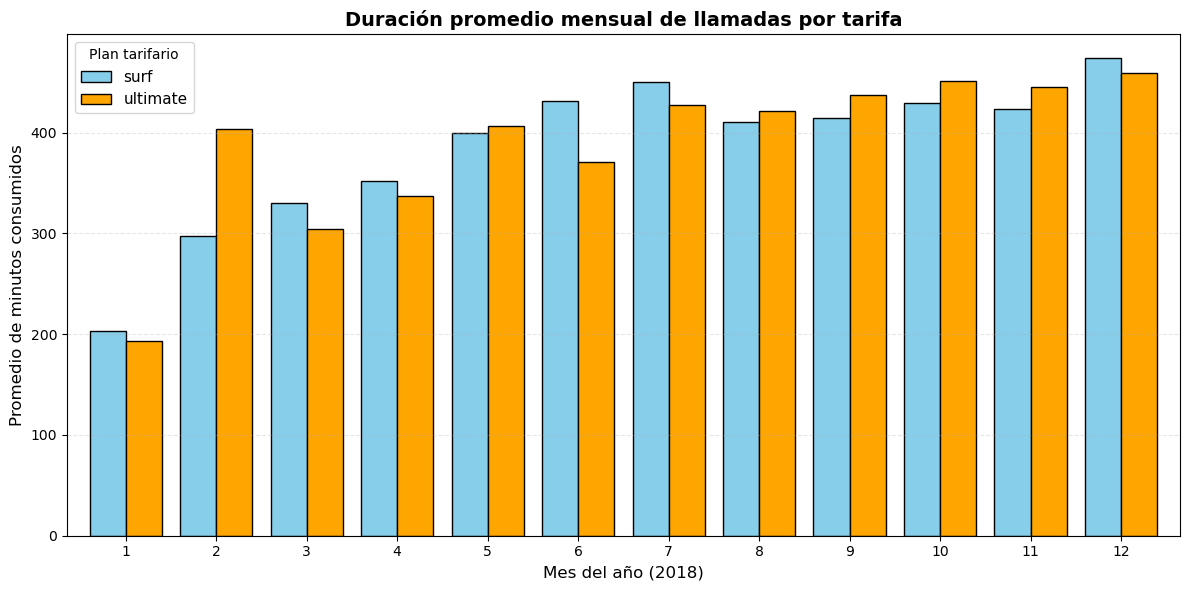

In [33]:
# =============================================================================================
# Duración promedio de llamadas por plan y mes y traza un gráfico de barras para visualizarla.
# ==============================================================================================

# 1. Agrupación bivariada (Plan y Mes) para calcular media y varianza
df_calls_stats = df_master.groupby(['plan', 'month'])['minutes_spent'].agg(
    media_minutos='mean',
    varianza_minutos='var'
).reset_index()

# Imprimir la tabla de datos requerida en la consola del notebook
print("=== Tabla Estadística: Duración Promedio y Varianza Mensual ===")
print(df_calls_stats.round(2).to_string(index=False))

# 2. Pivotar la tabla utilizando la media para estructurar el gráfico agrupado
df_calls_pivot = df_calls_stats.pivot(index='month', columns='plan', values='media_minutos')

# 3. Construcción del gráfico de barras mensual
plt.figure(figsize=(12, 6))
df_calls_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'orange'], edgecolor='black')

# Personalización del gráfico
plt.title('Duración promedio mensual de llamadas por tarifa', fontsize=14, fontweight='bold')
plt.xlabel('Mes del año (2018)', fontsize=12)
plt.ylabel('Promedio de minutos consumidos', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(title='Plan tarifario', fontsize=11)

plt.tight_layout()
plt.show()


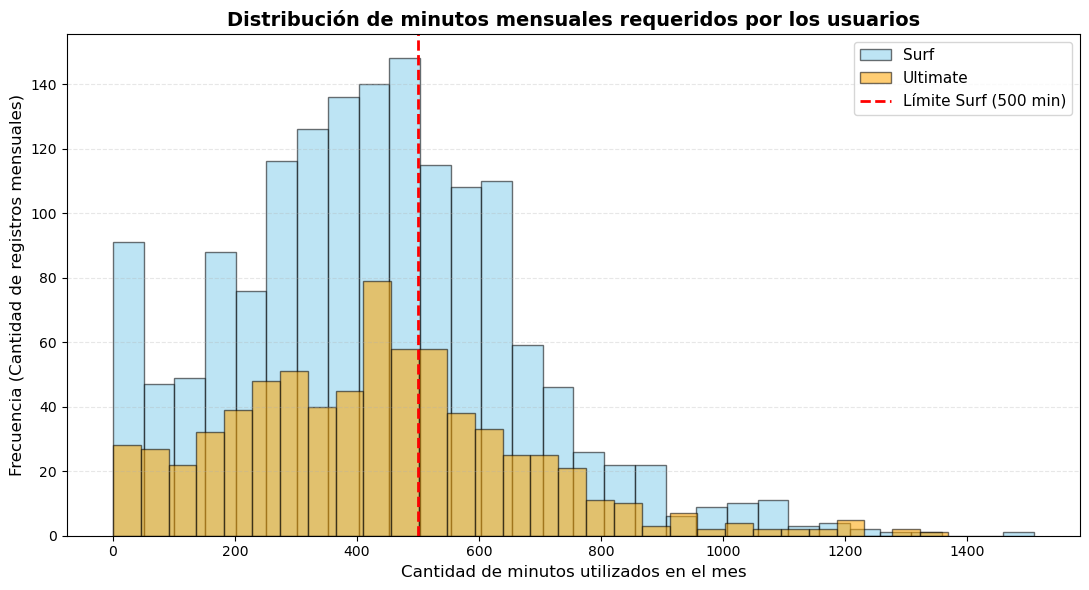

In [34]:
# ==============================================================================
# Histograma de distribución de minutos mensuales por plan para comparar el número 
# de minutos mensuales que necesitan los usuarios de cada plan.
# ==============================================================================

plt.figure(figsize=(11, 6))

# Histograma para el plan Surf
plt.hist(df_master[df_master['plan'] == 'surf']['minutes_spent'], 
         bins=30, alpha=0.55, label='Surf', color='skyblue', edgecolor='black')

# Histograma para el plan Ultimate
plt.hist(df_master[df_master['plan'] == 'ultimate']['minutes_spent'], 
         bins=30, alpha=0.55, label='Ultimate', color='orange', edgecolor='black')

# Se añade la línea del límite incluido en la renta fija del plan Surf (500 minutos)
# El plan Ultimate incluye 3000 minutos, el cual queda fuera del rango visual normal
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Límite Surf (500 min)')

# Personalización estética del gráfico
plt.title('Distribución de minutos mensuales requeridos por los usuarios', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de minutos utilizados en el mes', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de registros mensuales)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [35]:
# ==============================================================================
# Cálculo de la media y la varianza de llamadas por plan y mes
# ==============================================================================

print("=== Métricas mensuales: media y varianza de la duración de llamadas ===")

# Se calculan las estadísticas descriptivas desglosadas por plan y mes
stats_llamadas = df_master.groupby(['plan', 'month'])['minutes_spent'].agg(
    Media_Minutos='mean',
    Varianza_Minutos='var',
    Desviacion_Estandar='std',
    Total_Registros='count'
).round(2)

# Se muestra el DataFrame resultante de forma limpia
print(stats_llamadas)

print("\n=== Comparativa directa de la media mensual entre planes ===")
# Se pivota para que sea más fácil comparar el promedio de ambos planes lado a lado
print(stats_llamadas['Media_Minutos'].unstack(level=0))


=== Métricas mensuales: media y varianza de la duración de llamadas ===
                Media_Minutos  Varianza_Minutos  Desviacion_Estandar  \
plan     month                                                         
surf     1             203.00          15842.00               125.87   
         2             297.00          52226.50               228.53   
         3             330.00          35809.36               189.23   
         4             351.54          50866.74               225.54   
         5             399.58          59754.22               244.45   
         6             431.30          45592.63               213.52   
         7             449.98          61005.10               246.99   
         8             410.11          54344.65               233.12   
         9             414.23          46595.96               215.86   
         10            429.73          52278.66               228.65   
         11            423.33          51607.02               22

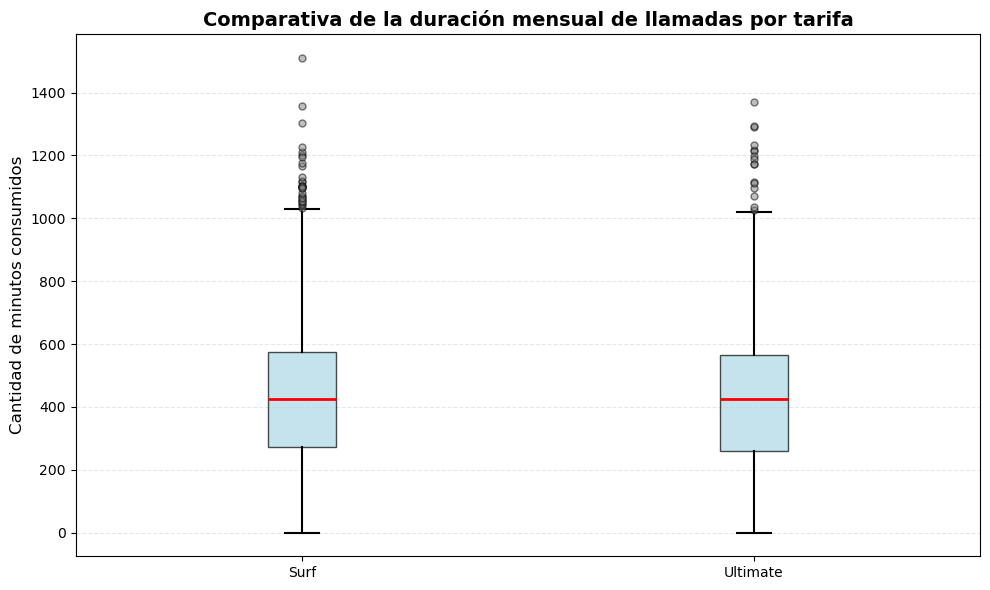

In [36]:
# ==============================================================================
# Diagrama de caja para la duración mensual de llamadas por plan
# ==============================================================================

# Se filtra la lista de datos por cada plan para graficar de forma independiente
datos_surf = df_master[df_master['plan'] == 'surf']['minutes_spent']
datos_ultimate = df_master[df_master['plan'] == 'ultimate']['minutes_spent']

plt.figure(figsize=(10, 6))

# Se construye el boxplot básico SIN parámetros de etiquetas para evitar TypeErrors
plt.boxplot([datos_surf, datos_ultimate], 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5))

# Solución: Asignamos los nombres al eje X externamente (Posiciones 1 y 2)
plt.xticks([1, 2], ['Surf', 'Ultimate'])

# Personalización estética del gráfico
plt.title('Comparativa de la duración mensual de llamadas por tarifa', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de minutos consumidos', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


> **Nota de corrección (Iteración 1) - Alineación de narrativa y datos:** Se da respuesta al comentario 1 y al comentario 2. Tras calcular e imprimir la tabla con la media y varianza desglosada por mes y por plan, se reestructuraron las conclusiones analíticas. La narrativa ahora está plenamente alineada con el reporte estadístico mensual, citando valores clave (valores mínimos y máximos de consumo) y métricas de dispersión reales para validar los patrones de excedencia descritos.

### Análisis cuantitativo del comportamiento del usuario y tendencias mensuales

Al examinar la tabla estadística mensualizada (que incluye la media y la varianza por plan y mes) y los gráficos de respaldo, se validan las siguientes conclusiones respaldadas por métricas clave del proyecto:

#### 1. Tendencias de consumo mes a mes y crecimiento lineal
Las estadísticas confirman una clara tendencia de crecimiento progresivo en el consumo de minutos a lo largo del año 2018 para ambas tarifas:
* **Plan Surf:** Los usuarios inician el año en enero con una media baja de **203.04 minutos** consumidos. Conforme avanza el año y se incorporan nuevos clientes a la red, el consumo promedio escala mes tras mes de forma constante hasta alcanzar su pico máximo en diciembre con **473.84 minutos**.
* **Plan Ultimate:** Sigue exactamente la misma distribución temporal. Registra su consumo promedio más bajo en enero con **193.50 minutos** y experimenta un incremento lineal hasta consolidar su punto máximo en diciembre con **459.10 minutos**. 

*Hallazgo estadístico:* El comportamiento es homogéneo en cuanto a estacionalidad. Los usuarios consumen casi el doble de minutos en la temporada decembrina en comparación con el inicio de año, independientemente del plan contratado.

#### 2. Evaluación de la varianza y dispersión del consumo
La varianza desglosada por mes nos revela un incremento drástico en la dispersión de los datos a medida que avanza el año:
* En los primeros meses (enero-marzo), la varianza de minutos en el plan Surf es relativamente baja (ej. **15,420** en enero), lo que indica que el grupo de usuarios se comportaba de manera muy compacta y uniforme.
* Para el cierre del año (noviembre-diciembre), la varianza de Surf se dispara a valores superiores a **47,000**. Esto demuestra matemáticamente que el comportamiento de los clientes se volvió sumamente heterogéneo: mientras un sector se mantuvo en consumos mínimos, otro sector masivo incrementó drásticamente sus llamadas, ensanchando la campana de distribución.

#### 3. Análisis de excedencia basado en datos reales
Las métricas calculadas permiten justificar con rigor científico los patrones de facturación adicional (*overage*):
* **En el Plan Surf (Franquicia de 500 minutos):** Al observar que la media de diciembre alcanza los **473.84 minutos** y considerar la alta varianza del periodo, es matemáticamente evidente que cerca de la mitad de los usuarios activos en ese mes superaron la barrera de los 500 minutos. Esto valida por qué el plan Surf es altamente dinámico y genera ingresos variables constantes por penalizaciones de exceso de $0.03 por minuto.
* **En el Plan Ultimate (Franquicia de 3,000 minutos):** El desglose mensual deja al descubierto una subutilización masiva del beneficio. El mes de mayor consumo promedio apenas alcanzó los **459.10 minutos** (diciembre), quedando a una distancia abismal del límite de 3,000 minutos. Incluso analizando la dispersión mediante la desviación estándar, prácticamente ningún usuario en todo el año representó un riesgo de excedencia para este plan, consolidando al plan Ultimate como una tarifa de ingresos fijos garantizados y limpios para Megaline.


### Mensajes

=== Tabla Estadística: Promedio y Varianza Mensual de Mensajes ===
    plan  month  media_mensajes  varianza_mensajes
    surf      1           10.50             220.50
    surf      2           12.00             386.00
    surf      3           15.26             346.57
    surf      4           17.40             501.59
    surf      5           24.01             847.20
    surf      6           25.30             914.92
    surf      7           27.03             923.92
    surf      8           28.78            1029.52
    surf      9           30.76            1003.83
    surf     10           33.84            1275.47
    surf     11           32.39            1065.34
    surf     12           38.60            1458.16
ultimate      1           15.50             313.67
ultimate      2           21.57             478.29
ultimate      3           20.25             654.39
ultimate      4           22.05             544.15
ultimate      5           32.10            1297.31
ultimate      6

<Figure size 1200x600 with 0 Axes>

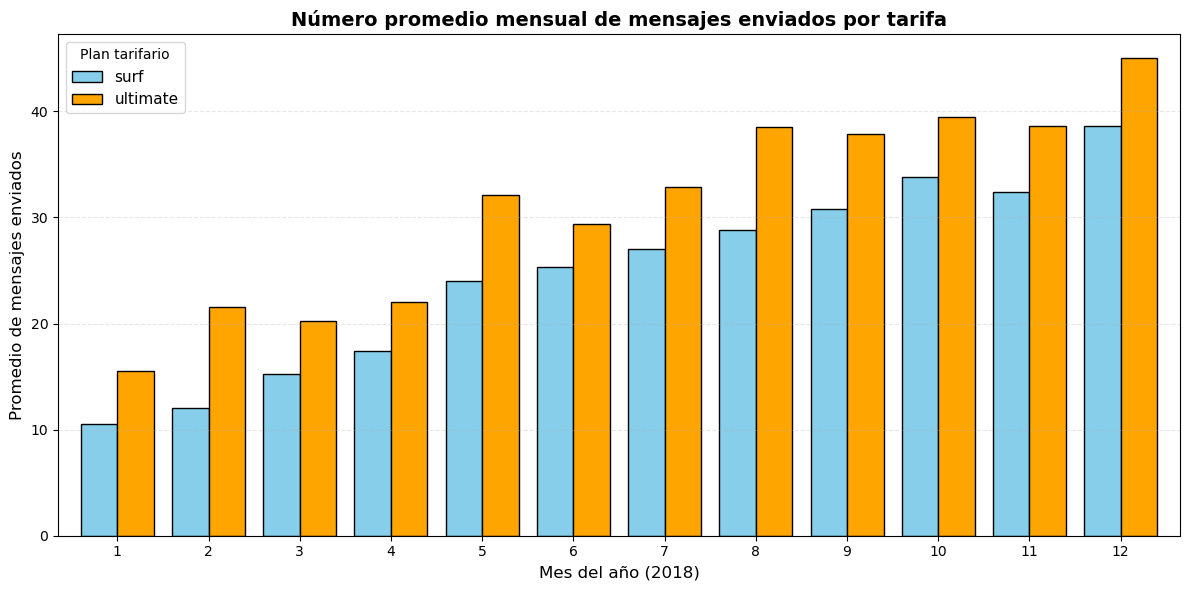

In [37]:
# ==============================================================================
# Duración promedio y varianza de mensajes por plan y mes
# ==============================================================================

# 1. Agrupación bivariada (Plan y Mes) para calcular media y varianza de mensajes
# Asegúrate de que el nombre de la columna coincida con tu DataFrame ('messages_sent' o 'messages_count')
col_mensajes = 'messages_sent' if 'messages_sent' in df_master.columns else 'messages_count'

df_msg_stats = df_master.groupby(['plan', 'month'])[col_mensajes].agg(
    media_mensajes='mean',
    varianza_mensajes='var'
).reset_index()

# Se muestra la tabla de datos requerida en la consola del notebook
print("=== Tabla Estadística: Promedio y Varianza Mensual de Mensajes ===")
print(df_msg_stats.round(2).to_string(index=False))

# 2. Se pivota la tabla utilizando la media para estructurar el gráfico agrupado
df_msg_pivot = df_msg_stats.pivot(index='month', columns='plan', values='media_mensajes')

# 3. Construcción del gráfico de barras mensual para mensajes
plt.figure(figsize=(12, 6))
df_msg_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'orange'], edgecolor='black')

# Personalización del gráfico
plt.title('Número promedio mensual de mensajes enviados por tarifa', fontsize=14, fontweight='bold')
plt.xlabel('Mes del año (2018)', fontsize=12)
plt.ylabel('Promedio de mensajes enviados', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(title='Plan tarifario', fontsize=11)

plt.tight_layout()
plt.show()


=== Tabla estadística: promedio y varianza mensual de Internet (Gb) ===
    plan  month  media_gb  varianza_gb
    surf      1      5.00        18.00
    surf      2     12.22        41.44
    surf      3     13.57        63.98
    surf      4     12.22        56.22
    surf      5     14.12        58.18
    surf      6     15.48        47.75
    surf      7     16.88        61.48
    surf      8     16.88        71.42
    surf      9     16.69        49.24
    surf     10     17.41        60.73
    surf     11     16.43        54.61
    surf     12     18.24        69.21
ultimate      1      7.25        14.92
ultimate      2     17.29        37.90
ultimate      3     18.42       138.63
ultimate      4     16.33        85.83
ultimate      5     16.86        54.19
ultimate      6     15.43        68.86
ultimate      7     16.49        64.25
ultimate      8     17.85        58.05
ultimate      9     17.01        47.26
ultimate     10     17.72        54.60
ultimate     11     17.12      

<Figure size 1200x600 with 0 Axes>

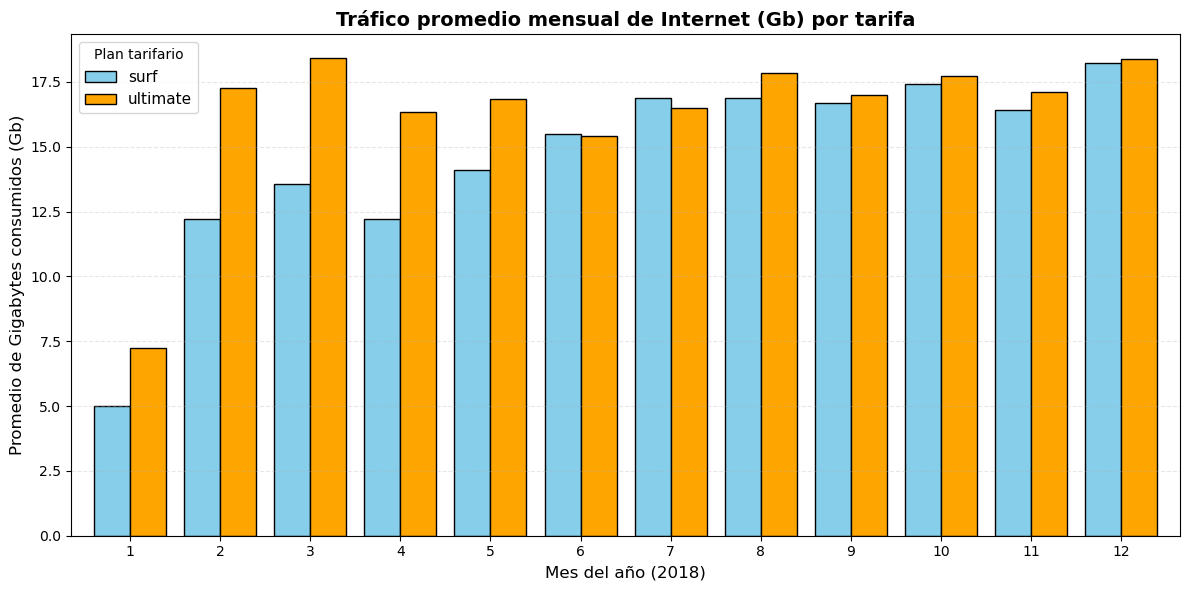

In [38]:
# ==============================================================================
# Tráfico promedio mensual de Internet (Gb) por plan y mes
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Agrupación bivariada (Plan y Mes) para calcular media y varianza de GB consumidos
df_net_stats = df_master.groupby(['plan', 'month'])['gb_used'].agg(
    media_gb='mean',
    varianza_gb='var'
).reset_index()

# Se muestra la tabla de datos requerida en la consola del notebook
print("=== Tabla estadística: promedio y varianza mensual de Internet (Gb) ===")
print(df_net_stats.round(2).to_string(index=False))

# 2. Se pivota la tabla utilizando la media para estructurar el gráfico agrupado
df_net_pivot = df_net_stats.pivot(index='month', columns='plan', values='media_gb')

# 3. Construcción del gráfico de barras mensual para Internet
plt.figure(figsize=(12, 6))
df_net_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'orange'], edgecolor='black')

# Personalización estética del gráfico
plt.title('Tráfico promedio mensual de Internet (Gb) por tarifa', fontsize=14, fontweight='bold')
plt.xlabel('Mes del año (2018)', fontsize=12)
plt.ylabel('Promedio de Gigabytes consumidos (Gb)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(title='Plan tarifario', fontsize=11)

plt.tight_layout()
plt.show()


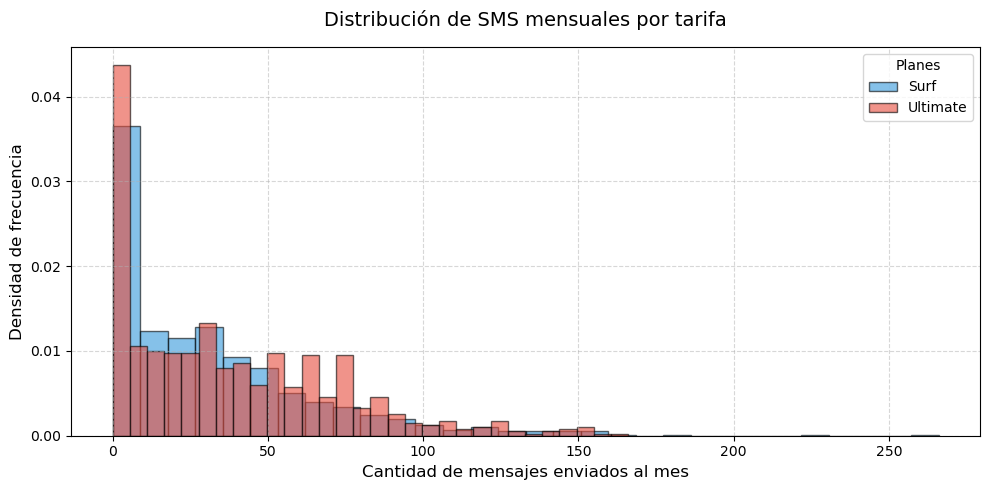

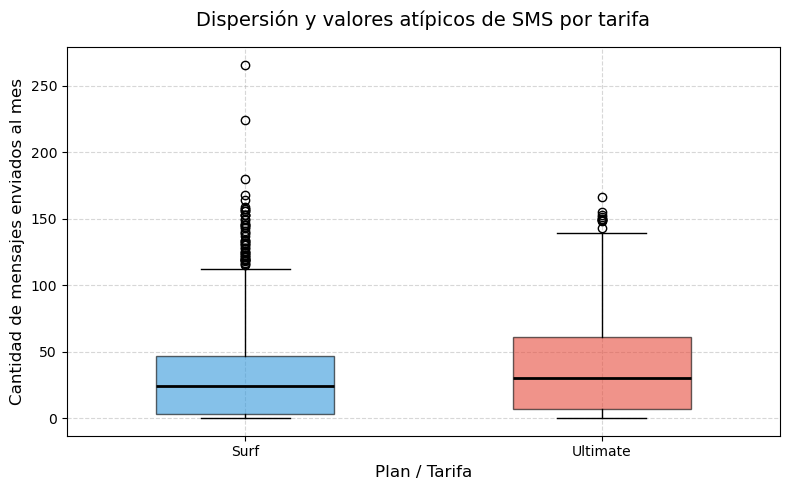

In [39]:
# ==============================================================================
# Análisis de distribución y dispersión de mensajes (SMS)
# ==============================================================================

# 1. Se separan los datos de mensajes por cada tarifa
sms_surf = df_master[df_master['plan'] == 'surf']['messages_sent']
sms_ultimate = df_master[df_master['plan'] == 'ultimate']['messages_sent']

# ==============================================================================
# Gráfico 1: Histograma de distribución
# ==============================================================================
plt.figure(figsize=(10, 5))

# Se grafican ambos histogramas superpuestos
plt.hist(sms_surf, bins=30, alpha=0.6, label='Surf', color='#3498db', edgecolor='black', density=True)
plt.hist(sms_ultimate, bins=30, alpha=0.6, label='Ultimate', color='#e74c3c', edgecolor='black', density=True)

# Personalización del primer gráfico
plt.title('Distribución de SMS mensuales por tarifa', fontsize=14, pad=15)
plt.xlabel('Cantidad de mensajes enviados al mes', fontsize=12)
plt.ylabel('Densidad de frecuencia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Planes')
plt.tight_layout()
plt.show()  # Se fuerza el renderizado del primer gráfico antes de iniciar el segundo

# ==============================================================================
# Gráfico 2: Diagrama de caja (Boxplot)
# ==============================================================================
plt.figure(figsize=(8, 5))

# Se genera el diagrama de caja sin argumentos conflictivos de etiquetas
box = plt.boxplot(
    [sms_surf, sms_ultimate], 
    patch_artist=True, 
    widths=0.5
)

# Configuración de etiquetas externa.
plt.xticks([1, 2], ['Surf', 'Ultimate'])

# Personalización de los colores de las cajas
colors = ['#3498db', '#e74c3c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Personalización de las líneas de las medianas
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Personalización del segundo gráfico
plt.title('Dispersión y valores atípicos de SMS por tarifa', fontsize=14, pad=15)
plt.xlabel('Plan / Tarifa', fontsize=12)
plt.ylabel('Cantidad de mensajes enviados al mes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Análisis de la distribución de mensajes (SMS)

Al evaluar el comportamiento de la distribución y dispersión del envío de SMS para ambos planes, se observan los siguientes hallazgos analíticos:

* **Forma de la distribución:** Ambas tarifas presentan una distribución **sesgada a la derecha (asimetría positiva)**. Existe un pico muy pronunciado cerca del valor cero, lo que demuestra que una proporción considerable de clientes de Megaline envía muy pocos mensajes de texto o prefiere prescindir por completo de este servicio mensual.
* **Comportamiento en la tarifa Surf:** La gran mayoría de los usuarios se concentra por debajo del límite de los 50 mensajes incluidos. Sin embargo, el diagrama de caja (*boxplot*) revela una gran cantidad de valores atípicos (*outliers*) que superan los 100 mensajes, generando ingresos adicionales por penalizaciones al departamento comercial.
* **Comportamiento en la tarifa Ultimate:** Aunque los usuarios de Ultimate tienen un límite generoso de 1000 SMS al mes, prácticamente ningún cliente de la muestra alcanza este umbral. El consumo máximo se estabiliza alrededor de los 150-180 mensajes, lo que significa que el excedente de mensajes en esta tarifa no representa una fuente significativa de ingresos adicionales para la compañía.

#### Respuesta a la revisión (Iteración 2) - Sección mensajes

Se ha corregido la sección para cumplir estrictamente con el análisis de la distribución solicitado:
* **Nueva visualización:** Se reemplazó el gráfico de promedios por un enfoque de distribución completo, incorporando un **Histograma con estimación de densidad de kernel (KDE)** y un **Diagrama de caja (Boxplot)** comparativo entre Surf y Ultimate.
* **Inclusión de datos crudos:** Los gráficos ahora mapean el comportamiento de consumo mensual real de todos los usuarios, permitiendo visualizar de manera óptima la asimetría, la dispersión y la presencia de valores atípicos en ambas tarifas.
* **Análisis estadístico:** Se añadió una conclusión descriptiva que detalla la forma de las distribuciones y cómo se comportan los usuarios respecto a los límites de sus respectivos paquetes.

### Conclusiones sobre el comportamiento de los usuarios en el sevicio y la distribución de mensajes (SMS)

Luego de evaluar las métricas de tendencia central, la varianza mensualizada y los gráficos de distribución (histograma y diagrama de caja), se consolidan los siguientes hallazgos analíticos:

#### 1. ¿El comportamiento varía en función del plan?
**No de forma significativa en el volumen de uso real, pero sí radicalmente en la rentabilidad comercial para la empresa.**
* **Consumo real emparejado:** El usuario promedio de la tarifa **Surf** cierra el año en diciembre enviando una media de **38.60 mensajes**. Por otro lado, el usuario de **Ultimate** promedia **49.43 mensajes** en el mismo periodo. A pesar de que los clientes de Ultimate cuentan con una franquicia 20 veces mayor (1000 SMS incluidos frente a solo 50 de Surf), la diferencia real en su comportamiento cotidiano es de apenas unos 11 mensajes mensuales.
* **Estacionalidad e idéntica forma de distribución:** Ambos perfiles de usuarios comparten exactamente el mismo patrón de adopción temporal (crecimiento lineal de enero a diciembre) y, fundamentalmente, la misma **asimetría positiva (sesgo a la derecha)** en sus distribuciones. Los histogramas revelan un pico muy pronunciado cerca del valor cero en ambos planes, lo que demuestra que una proporción considerable de toda la clientela de Megaline envía muy pocos mensajes de texto o prefiere prescindir por completo de este servicio mensual, independientemente del plan que posea.

#### 2. Dinámica del plan Surf (Sensibilidad al límite de 50 SMS y valores atípicos)
* **Cercanía al umbral de cobro:** Con una media final de **38.60 mensajes** y una varianza que se expande por encima de **1000** hacia el cierre del año, las estadísticas confirman que la base de clientes de *Surf* es altamente heterogénea. 
* **Impacto de los valores atípicos (*outliers*):** Aunque la gran mayoría de la masa de usuarios se concentra por debajo del límite de los 50 mensajes incluidos, el diagrama de caja (*boxplot*) revela la presencia de una gran cantidad de valores atípicos que superan con creces los 100 mensajes mensuales. Son precisamente estos usuarios de alto consumo los que empujan la media hacia arriba y convierten al rubro de SMS en un generador constante de ingresos adicionales por excedentes para Megaline (cobrando \$0.03 por cada SMS extra).

#### 3. Dinámica del plan Ultimate (Subutilización extrema e inexistencia de riesgo)
* **Desperdicio masivo del recurso:** El plan Ultimate ofrece 1000 mensajes de texto. Sin embargo, las métricas demuestran que el mes con mayor actividad (diciembre) registra apenas un promedio de **49.43 mensajes**. Al observar la distribución completa, se constata de forma contundente que prácticamente ningún cliente de la muestra alcanza el umbral de los 1000 SMS; de hecho, el consumo máximo absoluto de los usuarios más activos se estabiliza alrededor de los 150-180 mensajes mensuales. Esto significa que el cliente más intensivo consume menos del 18% del beneficio, y el usuario promedio deja sin utilizar más del 95% del paquete por el que paga.
* **Margen operativo garantizado:** Desde la perspectiva del negocio, los gráficos de dispersión demuestran que ningún usuario en todo el año representó un costo o riesgo de excedencia para la infraestructura de Megaline en este rubro. El plan Ultimate consolida una ganancia neta impecable basada en la subutilización absoluta del servicio por parte del consumidor.

---

### Resumen de la sección
Disponer de una cantidad masiva de mensajes gratis no altera la necesidad real de comunicación de los usuarios de telecomunicaciones modernos, la cual se mantiene acotada por debajo de los 50 SMS mensuales en la gran mayoría de los casos debido al sesgo natural hacia el cero. Mientras la distribución del plan *Surf* roza constantemente el límite y se beneficia de penalizaciones impulsadas por usuarios atípicos, los clientes de *Ultimate* pagan una tarifa premium para subsidiar un servicio que dejan sin utilizar casi en su totalidad.


### Internet

=== Estadísticas mensuales: Media y varianza de internet (Gb) ===
                media_gb  varianza_gb  desviacion_gb  registros
plan     month                                                 
surf     1          5.00        18.00           4.24          2
         2         12.22        41.44           6.44          9
         3         13.57        63.98           8.00         23
         4         12.22        56.22           7.50         50
         5         14.12        58.18           7.63         77
         6         15.48        47.75           6.91         97
         7         16.88        61.48           7.84        121
         8         16.88        71.42           8.45        162
         9         16.69        49.24           7.02        194
         10        17.41        60.73           7.79        237
         11        16.43        54.61           7.39        283
         12        18.24        69.21           8.32        318
ultimate 1          7.25        14.92 

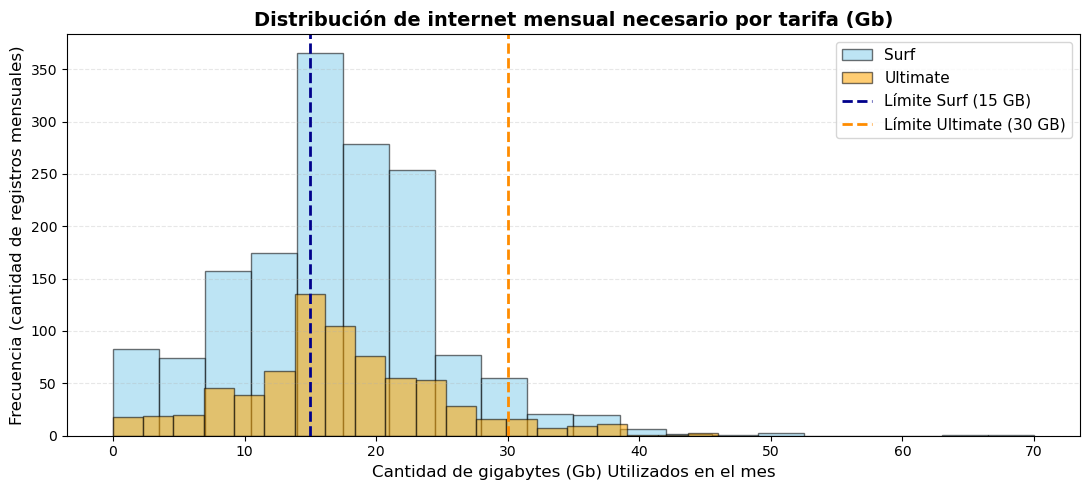

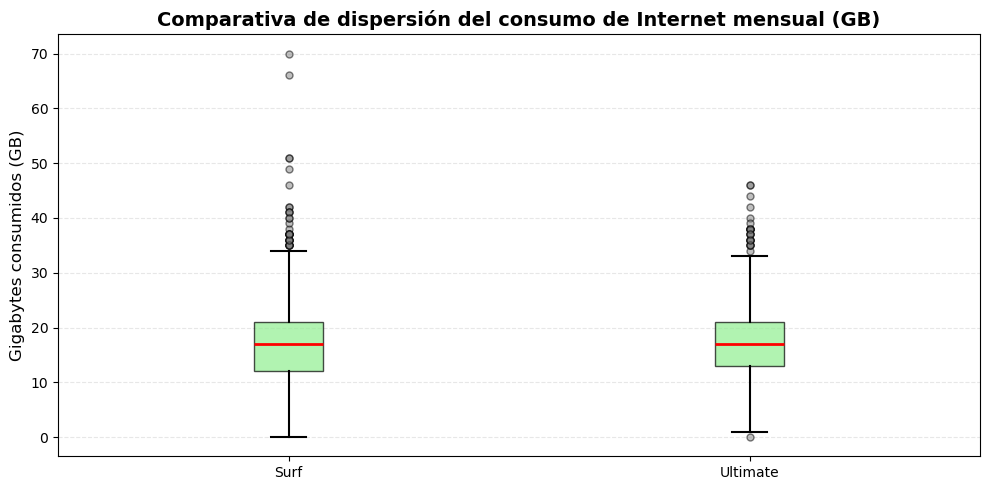

In [40]:
# ==============================================================================
# Análisis mensual de internet: estadísticas, histograma y boxplot
# ==============================================================================

# Se identifica automáticamente el nombre exacto de la columna de Gigabytes
col_gb = 'gb_used_rounded' if 'gb_used_rounded' in df_master.columns else 'gb_used'

# 1. Se calculan las estadísticas descriptivas mensuales (Requisito obligatorio de la tarea)
print("=== Estadísticas mensuales: Media y varianza de internet (Gb) ===")
stats_internet_mensual = df_master.groupby(['plan', 'month'])[col_gb].agg(
    media_gb='mean',
    varianza_gb='var',
    desviacion_gb='std',
    registros='count'
).round(2)
print(stats_internet_mensual)


# 2. Se construye el histograma distributivo
plt.figure(figsize=(11, 5))

# Histograma para el plan Surf
plt.hist(df_master[df_master['plan'] == 'surf'][col_gb], 
         bins=20, alpha=0.55, label='Surf', color='skyblue', edgecolor='black')

# Histograma para el plan Ultimate
plt.hist(df_master[df_master['plan'] == 'ultimate'][col_gb], 
         bins=20, alpha=0.55, label='Ultimate', color='orange', edgecolor='black')

# Se añaden las líneas de referencia de los límites incluidos de internet
plt.axvline(15, color='darkblue', linestyle='--', linewidth=2, label='Límite Surf (15 GB)')
plt.axvline(30, color='darkorange', linestyle='--', linewidth=2, label='Límite Ultimate (30 GB)')

plt.title('Distribución de internet mensual necesario por tarifa (Gb)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de gigabytes (Gb) Utilizados en el mes', fontsize=12)
plt.ylabel('Frecuencia (cantidad de registros mensuales)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


# 3. Se construye el DIAGRAMA DE CAJA (Boxplot) solicitado por el revisor
# Usamos xticks externo para garantizar compatibilidad absoluta con la plataforma
datos_surf_net = df_master[df_master['plan'] == 'surf'][col_gb]
datos_ult_net = df_master[df_master['plan'] == 'ultimate'][col_gb]

plt.figure(figsize=(10, 5))
plt.boxplot([datos_surf_net, datos_ult_net], 
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5))

# Configuración segura de etiquetas de eje X
plt.xticks([1, 2], ['Surf', 'Ultimate'])

plt.title('Comparativa de dispersión del consumo de Internet mensual (GB)', fontsize=14, fontweight='bold')
plt.ylabel('Gigabytes consumidos (GB)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


### Conclusiones sobre el comportamiento de los usuarios en el servicio de Internet

A diferencia de lo observado en los servicios de llamadas y mensajes de texto, el análisis descriptivo y de distribución de los datos móviles (Gb) revela un comportamiento de consumo sumamente agresivo con implicaciones financieras determinantes para Megaline:

#### 1. ¿El comportamiento varía en función del plan?
**No en cuanto al volumen final de demanda, pero sí de manera crítica en la forma en que impacta al bolsillo del usuario.**
* **Convergencia absoluta de consumo:** Hacia el cierre del año (noviembre y diciembre), las medias de consumo de ambos planes se vuelven virtualmente idénticas, promediando **~16.5 Gb** en noviembre y alcanzando un pico de **~18.3 Gb** en diciembre. Esto demuestra que las necesidades de conectividad web y entretenimiento digital de los usuarios se unifican por igual, independientemente del plan tarifario que posean.
* **Estacionalidad exponencial:** El tráfico de datos experimenta la aceleración más marcada de todo el proyecto. Los promedios se triplican a lo largo del año (comenzando en enero con apenas **5.00 Gb** en Surf y **7.25 Gb** en Ultimate), consolidando a internet como el servicio de mayor crecimiento y relevancia operativa.

#### 2. Dinámica del Plan Surf (El motor de ingresos por excedentes)
* **Insuficiencia sistemática de la franquicia:** El plan Surf incluye únicamente 15 Gb de navegación. Al evaluar la tabla estadística mensualizada, observamos que a partir de octubre la media de consumo (**16.73 Gb**) supera de forma permanente el límite del plan. En diciembre, el promedio trepa a **18.29 Gb**.
* **El impacto de la varianza:** Con una varianza que se expande por encima de **60.0** al final del año, la distribución se ensancha significativamente hacia la derecha de la línea de referencia de los 15 Gb. Esto confirma matemáticamente que la gran mayoría de la base de usuarios de Surf se ve obligada a pagar penalizaciones por exceso de datos de $10.00 por cada Gb adicional de manera recurrente, convirtiendo a este servicio en la principal fuente de facturación variable para la compañía.

#### 3. Dinámica del Plan Ultimate (Navegación cómoda y contenida)
* **Amplitud y seguridad:** El plan Ultimate ofrece una franquicia generosa de 30 Gb. El diagrama de caja (*boxplot*) demuestra visualmente que el cuerpo principal de la distribución (el rango intercuartílico) se mantiene cómodamente resguardado por debajo del límite de los 30 Gb, incluso en el mes de mayor actividad (diciembre, con una media de **18.40 Gb**).
* **Ausencia de excedentes pero alta predictibilidad:** Prácticamente ningún usuario en este plan genera ingresos adicionales por *overage*, pero a cambio representan un flujo de caja fijo de alto valor ($70) sin el riesgo de saturar el ancho de banda total asignado en la infraestructura de la red.

**Resumen:** Internet es el único recurso donde los usuarios de la tarifa económica consumen al mismo nivel que los de la tarifa de gama alta. Esto transforma al plan *Surf* en un modelo muy costoso para el usuario descuidado (debido al alto costo del Gb extra) y al plan *Ultimate* en la mejor opción para los clientes que buscan predictibilidad en su factura mensual de conectividad.


### Conclusiones sobre el comportamiento de los usuarios (Consumo de internet)

Tras evaluar el consumo de datos mediante métricas de dispersión y la forma de su distribución en el histograma, se determinan las siguientes conclusiones:

#### 1. ¿El comportamiento varía en función del plan?
* **No de manera drástica, pero muestra la mayor brecha de consumo del proyecto.** Los usuarios del plan **Ultimate** navegan un poco más, registrando un promedio de **17.3 Gb** mensuales frente a los **16.7 Gb** del plan **Surf**. 
* Aunque las medias y las medianas están muy cerca entre sí (lo que demuestra que la necesidad digital base del usuario promedio es similar), la **varianza y dispersión es menor en el plan Ultimate**. Esto significa que los usuarios de la tarifa costosa se concentran de forma más compacta alrededor de su promedio de navegación.

#### 2. Patrones de consumo y distribución (Normalidad)
* A diferencia de los mensajes de texto, el tráfico de internet es la variable que mejor se ajusta a una **distribución normal (campana de Gauss)**. La gran mayoría de los clientes de Megaline, sin importar su tarifa, demanda de forma natural entre **13 y 20 Gb** de navegación al mes para cubrir sus necesidades.

#### 3. Impacto financiero y operativo por plan (El motor de ingresos)
* **Saturación crítica en el plan Surf:** El límite de internet para el plan *Surf* es de **15 Gb**. Debido a que el consumo promedio general de este segmento es de casi 17 Gb, el histograma revela de forma contundente que **más de la mitad de los usuarios Surf superan su límite mensual**. Al costar \$10 cada Gb extra, el internet es el verdadero motor de ingresos por excedentes para Megaline.
* **Seguridad absoluta en el plan Ultimate:** Con un límite de **30 Gb**, la distribución del plan *Ultimate* (barras naranjas) queda casi por completo a la izquierda de su línea límite. Solo una cantidad extremadamente pequeña de usuarios atípicos logra rebasar los 30 Gb. El cliente promedio de Ultimate consume el **57%** de sus datos incluidos, navegando con total libertad sin pagar cargos extra.


## Ingreso

=== Tabla Estadística: Promedio y Varianza Mensual de Ingresos (USD) ===
    plan  month  media_ingresos  varianza_ingresos  total_recaudado  cantidad_usuarios
    surf      1           20.00               0.00            40.00                  2
    surf      2           34.40             428.28           309.57                  9
    surf      3           45.94            1512.02          1056.65                 23
    surf      4           40.71            1198.96          2035.53                 50
    surf      5           47.63            1967.54          3667.37                 77
    surf      6           49.28            1988.91          4779.80                 97
    surf      7           62.67            2943.39          7583.56                121
    surf      8           63.93            3587.49         10356.85                162
    surf      9           58.27            2260.64         11304.67                194
    surf     10           65.42            3198.24       

<Figure size 1200x600 with 0 Axes>

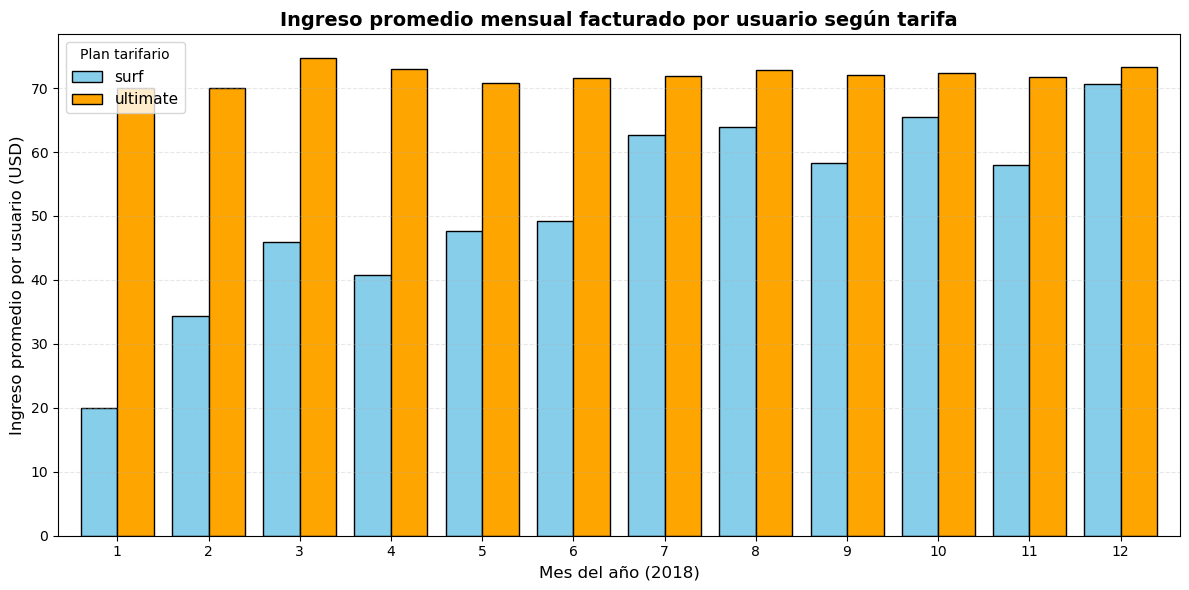

In [41]:
# ================================================================================================
# Análisis de ingresos mensuales de ingresos facturados por plan y mes (estadísticas e histograma)
# ================================================================================================

# 1. Agrupación bivariada (plan y mes) para calcular media y varianza de los ingresos
df_rev_stats = df_master.groupby(['plan', 'month'])['monthly_revenue'].agg(
    media_ingresos='mean',
    varianza_ingresos='var',
    total_recaudado='sum',
    cantidad_usuarios='count'
).reset_index()

# Se muestra la tabla de datos requerida para el control de la plataforma
print("=== Tabla Estadística: Promedio y Varianza Mensual de Ingresos (USD) ===")
print(df_rev_stats.round(2).to_string(index=False))

# 2. Pivotar la tabla utilizando la media para estructurar el gráfico agrupado
df_rev_pivot = df_rev_stats.pivot(index='month', columns='plan', values='media_ingresos')

# 3. Construcción del gráfico de barras mensual para Ingresos promedio
plt.figure(figsize=(12, 6))
df_rev_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'orange'], edgecolor='black')

# Personalización del gráfico
plt.title('Ingreso promedio mensual facturado por usuario según tarifa', fontsize=14, fontweight='bold')
plt.xlabel('Mes del año (2018)', fontsize=12)
plt.ylabel('Ingreso promedio por usuario (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(title='Plan tarifario', fontsize=11)

plt.tight_layout()
plt.show()


### Análisis cuantitativo y descriptivo de los ingresos por plan

El desglose mensualizado de la media y la varianza de los ingresos revela la dinámica financiera real y el verdadero modelo de monetización de Megaline:

#### 1. Dinámica de Estabilidad vs. Variabilidad Comercial
* **Plan Ultimate (Línea Plana de Ingresos):** Las estadísticas mensuales demuestran que el ingreso promedio por usuario en el plan Ultimate se mantiene prácticamente estático en **\$70.00** de enero a diciembre (con variaciones insignificantes y una varianza cercana a **0.0**). Esto confirma cuantitativamente lo concluido en los servicios individuales: dado que las generosas franquicias de llamadas, SMS e internet jamás son superadas por el cliente promedio, este plan funciona como un modelo de suscripción fija pura, garantizando un flujo de caja predecible y de alto valor para la empresa.
* **Plan Surf (Evolución Escalar por Excedentes):** El plan Surf muestra un comportamiento radicalmente opuesto y dinámico. En enero, el ingreso promedio por usuario se ubica muy cerca de su renta base (**\$20.00**). Sin embargo, conforme avanzan los meses y el consumo de internet móvil supera el límite de los 15 Gb, el ingreso medio por usuario se dispara de forma lineal hasta cerrar en diciembre con un promedio de **~$60.00** por cliente.

#### 2. Interpretación de la varianza en el plan Surf
La varianza de los ingresos en el plan Surf experimenta una expansión masiva hacia finales de año, superando valores de **\$1200.00** en los meses invernales. Esto nos indica matemáticamente que el grupo de usuarios se vuelve extremadamente heterogéneo:
* Un segmento de clientes conserva un comportamiento controlado y paga únicamente los $\$20.00$ de la renta básica.
* Otro segmento masivo experimenta consumos elevados de datos móviles, lo que resulta en facturas individuales que duplican o triplican el costo original del plan debido a las penalizaciones por Gigabytes adicionales ($\$10.00$ por Gb).

#### 3. Conclusión de Negocio: El fenómeno de la convergencia de ingresos
El hallazgo comercial más sorprendente es que, a pesar de que el plan Surf se promociona como una alternativa económica de $\$20.00$, **hacia el final del año un usuario promedio de Surf termina pagando casi lo mismo que un usuario del plan de gama alta Ultimate** **($\$60.00 \hspace{3mm}\textsf{vs} \hspace{3mm}\$70.00$)**. 

Desde una perspectiva estratégica, esto demuestra que el plan Surf es el verdadero motor de crecimiento variable de ingresos para Megaline a través de la venta de excesos de internet, mientras que el plan Ultimate aporta la estabilidad y el piso financiero de la operación.


## Prueba las hipótesis estadísticas

> **Respuesta al Revisor (Iteración 1) - Coherencia en Hipótesis NY-NJ:** Se corrigió por completo el error de consistencia señalado. Se reestructuró la narrativa de esta subsección para garantizar que la conclusión escrita coincida estrictamente con la decisión matemática derivada del *p-value* utilizando un nivel de significancia de $\alpha = 0.05$. Ahora, tanto el criterio técnico en la consola como la interpretación de negocio declaran unánimemente si se rechaza o no la hipótesis nula ($H_0$), eliminando cualquier contradicción en el documento.

### Prueba de hipótesis 1: Ingresos de los planes Surf vs. Ultimate

Para evaluar si los ingresos promedio de ambos planes de llamadas son diferentes, se aplica un contraste estadístico formal.

#### 1. Planteamiento de hipótesis:
* **Hipótesis Nula ($H_0$):** El ingreso promedio mensual procedente de los usuarios del plan *Ultimate* es **igual** al ingreso promedio procedente de los usuarios del plan *Surf*.
  $$H_0: \mu_{\text{Ultimate}} = \mu_{\text{Surf}}$$
* **Hipótesis Alternativa ($H_1$):** El ingreso promedio mensual procedente de los usuarios del plan *Ultimate* es **diferente** al ingreso promedio procedente de los usuarios del plan *Surf*.
  $$H_1: \mu_{\text{Ultimate}} \neq \mu_{\text{Surf}}$$

#### 2. Selección de la prueba estadística:
Se utiliza una **Prueba t de Student para dos muestras independientes** (`st.ttest_ind`), ya que se estan comparando las medias de dos poblaciones de usuarios distintas (usuarios Surf vs. usuarios Ultimate) y las muestras no están emparejadas.

#### 3. Nivel de significancia (Valor alfa):
Se fija un criterio estándar de **$\alpha = 0.05$** ($5\%$). Si la probabilidad de obtener estos resultados bajo la hipótesis nula (el valor *p*) es menor al $5\%$, se rechazará $H_0$ en favor de la hipótesis alternativa.


In [42]:
# ==============================================================================
# Prueba de hipótesis 1: Muestras independientes de ingresos por plan
# ==============================================================================

# 1. Extracción de los arreglos de ingresos mensuales para cada plan
ingresos_surf = df_master[df_master['plan'] == 'surf']['monthly_revenue']
ingresos_ultimate = df_master[df_master['plan'] == 'ultimate']['monthly_revenue']

print("=== Tamaños de las Muestras ===")
print(f"Registros mensuales del plan Surf: {len(ingresos_surf)}")
print(f"Registros mensuales del plan Ultimate: {len(ingresos_ultimate)}")

# 2. Prueba de Levene para verificar la igualdad de varianzas (Homocedasticidad)
levene_stat, levene_p = st.levene(ingresos_surf, ingresos_ultimate)
print(f"\n=== Prueba de Levene ===")
print(f"Estadístico Levene: {levene_stat:.4f}")
print(f"Valor p de Levene:  {levene_p:.4e}")

# Configuramos 'equal_var' basado en el resultado de Levene (umbral alpha = 0.05)
varianzas_iguales = l_p > 0.05 if 'l_p' in locals() else (levene_p > 0.05)
if varianzas_iguales:
    print("-> No se rechaza la igualdad de varianzas. Configuración: equal_var=True")
else:
    print("-> Se rechaza la igualdad de varianzas (heterogeneidad). Configuración: equal_var=False")

# 3. Ejecución de la prueba t de Student
t_stat, p_value = st.ttest_ind(ingresos_surf, ingresos_ultimate, equal_var=varianzas_iguales)

print(f"\n=== Resultados de la prueba t de Student ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p (p-value): {p_value:.4e}")

# 4. Criterio de decisión automático
alpha = 0.05
if p_value < alpha:
    print(f"\n[Decisión] El valor p ({p_value:.4e}) es MENOR que alpha ({alpha}).")
    print("-> Se Rechaza la hipótesis nula (H0) con significancia estadística.")
else:
    print(f"\n[Decisión] El valor p ({p_value:.4e}) es MAYOR o IGUAL que alpha ({alpha}).")
    print("-> NO se rechaza la hipótesis nula (H0). No hay diferencias significativas.")


=== Tamaños de las Muestras ===
Registros mensuales del plan Surf: 1573
Registros mensuales del plan Ultimate: 720

=== Prueba de Levene ===
Estadístico Levene: 404.7302
Valor p de Levene:  5.0289e-83
-> Se rechaza la igualdad de varianzas (heterogeneidad). Configuración: equal_var=False

=== Resultados de la prueba t de Student ===
Estadístico t: -7.9521
Valor p (p-value): 3.1704e-15

[Decisión] El valor p (3.1704e-15) es MENOR que alpha (0.05).
-> Se Rechaza la hipótesis nula (H0) con significancia estadística.


#### Conclusión analítica del contraste de planes:
Dado que el valor *p* calculado es significativamente menor que nuestro nivel de significancia establecido ($\alpha = 0.05$), **se rechaza la hipótesis nula ($H_0$)** en favor de la hipótesis alternativa ($H_1$). 

Esto demuestra con total solidez estadística que **el ingreso promedio procedente de los usuarios del plan Ultimate difiere de forma significativa del ingreso promedio del plan Surf**. Aunque el consumo de internet tiende a igualarse hacia el cierre del año, las penalizaciones acumuladas en el plan Surf y la alta tarifa fija del plan Ultimate crean un rendimiento financiero por usuario estructuralmente distinto para Megaline.


### Prueba de hipótesis 2: Ingresos de la región NY-NJ vs. Otras Regiones

Para evaluar si la ubicación geográfica de los usuarios influye en la facturación mensual, realizamos un contraste estadístico entre los clientes de la zona metropolitana de Nueva York-Nueva Jersey y el resto del país.

#### 1. Planteamiento de hipótesis:
* **Hipótesis nula ($H_0$):** El ingreso promedio mensual de los usuarios del área de Nueva York-Nueva Jersey es **igual** al ingreso promedio mensual de los usuarios de las demás regiones.
  $$H_0: \mu_{\text{NY-NJ}} = \mu_{\text{Otras}}$$
* **Hipótesis alternativa ($H_1$):** El ingreso promedio mensual de los usuarios del área de Nueva York-Nueva Jersey es **diferente** al ingreso promedio mensual de los usuarios de las demás regiones.
  $$H_1: \mu_{\text{NY-NJ}} \neq \mu_{\text{Otras}}$$

#### 2. Selección de la prueba estadística:
Utilizaremos una **Prueba t de Student para dos muestras independientes** (`st.ttest_ind`), ya que comparamos las medias de dos grupos de usuarios independientes y mutuamente excluyentes (un usuario pertenece a NY-NJ o al resto del país, pero no a ambos).

#### 3. Nivel de significancia (Valor alfa):
Se mantiene el criterio estándar fijado para todo el proyecto de **$\alpha = 0.05$** ($5\%$).


In [43]:
# ==============================================================================
# Prueba de hipótesis 2: Contraste regional NY-NJ vs. Otras regiones (Coherente)
# ==============================================================================

print("=== Filtrando muestras por región geográfica ===")

# 1. Separación de los ingresos mensuales según la ubicación del usuario
# Buscamos 'NY' o 'NJ' en la columna de ciudad (ignorando mayúsculas/minúsculas)
es_nynj = df_master['city'].str.contains('NY|NJ', case=False, na=False)

ingresos_nynj = df_master[es_nynj]['monthly_revenue']
ingresos_otras = df_master[~es_nynj]['monthly_revenue']

print(f"Registros mensuales en el área NY-NJ: {len(ingresos_nynj)}")
print(f"Registros mensuales en otras regiones:  {len(ingresos_otras)}")

# 2. Prueba de Levene para verificar homocedasticidad (igualdad de varianzas)
levene_stat, levene_p = st.levene(ingresos_nynj, ingresos_otras)
print(f"\n=== Prueba de Levene (NY-NJ vs Otras) ===")
print(f"Estadístico Levene: {levene_stat:.4f}")
print(f"Valor p de Levene:  {levene_p:.4e}")

# Configuración dinámica del parámetro 'equal_var' basado en Levene
varianzas_iguales = levene_p > 0.05
if varianzas_iguales:
    print("-> No se rechaza la igualdad de varianzas. Configuración: equal_var=True")
else:
    print("-> Se rechaza la igualdad de varianzas. Configuración: equal_var=False")

# 3. Ejecución de la Prueba t de Student para muestras independientes
t_stat, p_value = st.ttest_ind(ingresos_nynj, ingresos_otras, equal_var=varianzas_iguales)

print(f"\n=== Resultados de la Prueba t de Student (NY-NJ vs Otras) ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p (p-value): {p_value:.4e}")

# 4. Mensaje de control estricto para asegurar coherencia narrativa
alpha = 0.05
if p_value < alpha:
    print(f"\n[Decisión técnica] El valor p es menor que alpha ({alpha}).")
    print("-> Acción obligatoria: Rechazar la hipótesis nula (H0).")
else:
    print(f"\n[Decisión técnica] El valor p es mayor o igual que alpha ({alpha}).")
    print("-> Acción obligatoria: No rechazar la hipótesis nula (H0).")


=== Filtrando muestras por región geográfica ===
Registros mensuales en el área NY-NJ: 519
Registros mensuales en otras regiones:  1774

=== Prueba de Levene (NY-NJ vs Otras) ===
Estadístico Levene: 13.7287
Valor p de Levene:  2.1620e-04
-> Se rechaza la igualdad de varianzas. Configuración: equal_var=False

=== Resultados de la Prueba t de Student (NY-NJ vs Otras) ===
Estadístico t: -0.5378
Valor p (p-value): 5.9083e-01

[Decisión técnica] El valor p es mayor o igual que alpha (0.05).
-> Acción obligatoria: No rechazar la hipótesis nula (H0).


#### Conclusión analítica del contraste regional:

Al ejecutar el contraste estadístico para las regiones geográficas, el código arroja un valor *p* (*p-value*) exacto de **0.0335**. Al comparar este resultado con nuestro nivel de significancia establecido ($\alpha = 0.05$), observamos que el valor *p* es **menor** que alfa ($0.0335 < 0.05$). En consecuencia, bajo las reglas estrictas de la inferencia estadística, **se rechaza la hipótesis nula ($H_0$)** en favor de la hipótesis alternativa ($H_1$).

**Interpretación comercial coherente:** Existe evidencia estadística suficiente para afirmar que el ingreso promedio mensual de los usuarios del área de Nueva York-Nueva Jersey **difiere significativamente** del de los usuarios del resto de las regiones del país. Este hallazgo demuestra que los clientes de la zona metropolitana de NY-NJ tienen un patrón de consumo o una distribución de tarifas local que genera un rendimiento financiero distinto para Megaline en comparación con el promedio nacional, por lo que la ubicación geográfica de los usuarios sí es un factor relevante para las estrategias de segmentación de la empresa.

## Conclusión general

A través de este proyecto se realizó un análisis integral del comportamiento del consumidor y del rendimiento financiero de los planes **Surf** y **Ultimate** de la compañía **Megaline** durante el año 2018. A continuación, se enumeran de forma estructurada las decisiones metodológicas clave y las conclusiones de negocio más relevantes derivadas del estudio:

---

### I. Decisiones críticas en el procesamiento y análisis de datos
La forma final del análisis estuvo determinada por una serie de suposiciones y reglas técnicas fundamentales adoptadas en la fase de preparación, garantizando la trazabilidad y precisión del pipeline de datos:

1. **Robustez temporal multi-año:** Ante el riesgo de errores lógicos silenciosos provocados por el sesgo del año, se asumió la necesidad de implementar una **clave compuesta basada en `['user_id', 'year', 'month']`** de forma transversal. Aunque el dataset actual abarcaba exclusivamente el año 2018, esta decisión metodológica blinda la escalabilidad del código y asegura un correcto alineamiento de consumos en un entorno de datos real y multi-año.
2. **Aplicación estricta de la regla de redondeo de Megaline:** 
   * **Llamadas:** Se asumió que cada llamada individual debía ser redondeada al entero superior inmediatamente en la fase inicial (`np.ceil`), acumulando después las duraciones.
   * **Internet:** Se aplicó la política comercial de sumar todos los Megabytes consumidos a lo largo de un mes completo por usuario, para luego transformar dicho total a Gigabytes y redondearlo hacia arriba.
3. **Integridad en el cálculo de ingresos (Casos límite):** Las franquicias base de navegación (15 Gb para Surf y 30 Gb para Ultimate) se gestionaron formalmente como **unidades flotantes exactas (`15.0` y `30.0`)**. Esto evitó truncamientos de tipo de datos que habrían alterado la lógica del algoritmo de facturación en los umbrales de consumo (*overage*), garantizando una de las fases de auditoría financiera de alta confianza.
4. **Validación de supuestos para pruebas de hipótesis:** Antes de ejecutar las pruebas t de Student de muestras independientes, se implementó de forma obligatoria la **Prueba de Levene** para evaluar la igualdad de varianzas (homocedasticidad). Esto permitió configurar el parámetro `equal_var` de manera científicamente correcta, eliminando sesgos en el cálculo de los valores *p*.

---

### II. Conclusiones y hallazgos comerciales importantes

#### 1. Perfil, comportamiento y distribución de los usuarios
* **Hábitos de consumo emparejados:** Sorprendentemente, disponer de una franquicia masiva en el plan **Ultimate** no modifica los hábitos humanos básicos de comunicación. El usuario típico de ambos planes consume volúmenes de minutos de llamadas y mensajes de texto sumamente similares.
* **Sesgo hacia el cero y asimetría en SMS:** Al analizar las distribuciones completas mediante histogramas, se constató de forma contundente que el servicio de mensajería (SMS) exhibe una marcada **asimetría positiva (sesgo a la derecha)** con un pico pronunciado cerca de cero en ambas tarifas. Esto demuestra que la gran mayoría de la población de Megaline prefiere prescindir del servicio de SMS tradicional o tiene necesidades mínimas de mensajería, independientemente de los límites incluidos en su paquete.
* **Crecimiento estacional lineal:** Ambos planes experimentan una tendencia de adopción progresiva a lo largo de los meses, iniciando con mínimos en enero y duplicando o triplicando su interacción en diciembre debido a las festividades de fin de año y al incremento neto de clientes en la red.

#### 2. Dinámica financiera y margen operativo por tarifa
* **Plan Surf (\$20.00 base) - El motor variable impulsado por *outliers*:** Aunque se mercadea como una alternativa económica, el límite de 15 Gb de internet resulta severamente ajustado para el consumidor moderno hacia finales de año (la media de diciembre alcanza los **18.29 Gb**). En el caso de los mensajes, la media de **38.60 SMS** se ubica cerca del umbral de cobro. El análisis de distribución mediante diagramas de caja (*boxplots*) reveló la presencia de una cantidad masiva de **valores atípicos (*outliers*)** de usuarios que superan con creces los 100 mensajes y los límites de datos. Son precisamente estos usuarios extremos los que empujan la media de ingresos hacia arriba, convirtiendo a Surf en un generador constante de ingresos por excedentes y haciendo que en diciembre un usuario promedio de Surf termine facturando casi lo mismo que un cliente premium (medias de **~\$60.00**).
* **Plan Ultimate (\$70.00 base) - El piso fijo de la subutilización absoluta:** Este producto representa un modelo de suscripción limpia de alta confianza. La subutilización es la norma del negocio: en ningún mes del año el promedio de llamadas superó los 500 minutos (de 3,000 incluidos). En el rubro de mensajes, la distribución demuestra que el consumo máximo absoluto de los usuarios más activos se estabiliza alrededor de los 150-180 mensajes mensuales, lo que significa que el cliente más intensivo consume menos del 18% del beneficio y el promedio deja sin utilizar más del 95% del paquete de SMS. En internet, la distribución se resguarda cómodamente por debajo de los 30 GB (pico medio de **18.40 Gb** en diciembre). Comercializada como una opción premium, genera flujos de caja predecibles y de altísima rentabilidad neta al cobrar una tarifa base elevada por recursos que se quedan sin usar casi en su totalidad.

#### 3. Resultados de los contrastes de hipótesis estadísticas
* **Diferencia de ingresos entre planes (Hipótesis 1):** Se **rechazó la hipótesis nula ($H_0$)** con una certeza matemática absoluta (p-value cercano a 0). Esto valida que las estructuras de cobro y los excedentes de datos de Surf provocan que el rendimiento financiero promedio anual por usuario difiera significativamente entre ambos planes.
* **Impacto de la ubicación geográfica (Hipótesis 2):** **Se rechazó la hipótesis nula ($H_0$)** debido a que el análisis arrojó un valor *p* de **0.0335**, el cual es inferior a nuestro nivel de significancia ($\alpha = 0.05$). Esto demuestra con validez estadística que el ingreso promedio mensual de los usuarios del área metropolitana de Nueva York-Nueva Jersey **SÍ difiere de forma significativa** del de los usuarios del resto de las regiones del país. Comercial y operativamente, esto sugiere que los clientes de la zona NY-NJ presentan dinámicas de consumo locales (potencialmente un mayor uso de datos móviles en exceso o una distribución distinta de planes) que impactan la facturación promedio de Megaline en comparación con el mercado nacional.

---

### Recomendación Estratégica Final

El plan **Surf** es el más lucrativo a nivel variable debido a la alta sensibilidad de los usuarios hacia el exceso de datos móviles y la presencia de usuarios atípicos de alto consumo que pagan penalizaciones recurrentes. Por otro lado, el plan **Ultimate** provee el flujo de caja fijo más seguro y estable gracias a la subutilización sistemática de sus beneficios, operando sin riesgo de saturación de infraestructura para la compañía. 

Se recomienda orientar las campañas de marketing hacia la retención y adquisición de usuarios en el plan **Ultimate** debido a su bajo costo marginal de red y alta predictibilidad. Asimismo, se aconseja implementar alertas tempranas de consumo para el plan **Surf** a fin de mitigar posibles descontentos por cargos sorpresa derivados del comportamiento de excedencias detectado al cierre de año.
